# Portfolio Optimization Results Analysis

This notebook analyzes results from three optimization approaches:
- **QUBO** - Modern QUBO optimization with diversification constraints
- **Sharpe Optimization** - Sharpe ratio optimization with diversification constraints
- **Legacy QUBO** - Legacy QUBO implementation

Includes D-Wave results where available and synthetic dataset analysis.

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import glob
import sys
import os

# Add parent directory to path to import from util
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# Import all utilities from util.analysis_plotting
from util.analysis_plotting import (
    # Style and configuration
    apply_style,
    COLORS,
    SOLVER_COLORS,
    FONT_SIZES,
    FIGURE_SIZES,
    
    # Plotting functions
    plot_cumulative_returns,
    plot_multi_period_comparison,
    plot_performance_comparison,
    plot_performance_summary_table,
    plot_weight_distribution_histograms,
    plot_weight_heatmap,
    plot_execution_times,
    plot_risk_return_scatter,
    
    # Data loading and analysis functions
    load_pickle_result,
    analyze_performance,
    extract_weights_from_results,
    multi_comparison,
    analyze_dataset,
    
    # Utility functions
    save_figure,
    close_all_figures
)

# Apply consistent plotting style
apply_style()

print("✓ Analysis utilities loaded successfully")

✓ Analysis utilities loaded successfully


## Load Results from All Methods

In [2]:
def load_all_results(results_dir, method_name):
    """Load all results from a directory."""
    results = []
    
    pickle_files = glob.glob(os.path.join(results_dir, '*.pkl'))
    
    print(f"Loading {method_name}...")
    print(f"  Directory: {results_dir}")
    print(f"  Found {len(pickle_files)} files")
    
    for file_path in pickle_files:
        basename = os.path.basename(file_path)
        
        # Parse different filename patterns
        if 'legacy_qubo' in results_dir:
            # Pattern: results_{dataset}_{period}_{solver}.pkl
            parts = basename.replace('.pkl', '').split('_')
            if len(parts) >= 4:
                dataset = parts[1]
                period = int(parts[2])
                solver = parts[3]
            else:
                continue
        else:
            # Pattern: results_{solver}_{period}.pkl or results_{dataset}_{solver}_{period}.pkl
            parts = basename.replace('.pkl', '').split('_')
            if len(parts) == 3:
                # results_{solver}_{period}.pkl
                dataset = 'main'
                solver = parts[1]
                period = int(parts[2])
            elif len(parts) == 4:
                # results_{dataset}_{solver}_{period}.pkl
                dataset = parts[1]
                solver = parts[2]
                period = int(parts[3])
            else:
                continue
        
        data = load_pickle_result(file_path)
        
        if data is not None:
            portfolio_returns = data.get('portfolio_cumulative_returns', [])
            benchmark_returns = data.get('benchmark_cumulative_returns', [])
            execution_time = data.get('total_run_time', 0)
            start_date = data.get('start_date')
            end_date = data.get('end_date')
            
            final_return = None
            if portfolio_returns is not None:
                try:
                    if hasattr(portfolio_returns, '__len__') and len(portfolio_returns) > 0:
                        final_return = portfolio_returns[-1]
                except:
                    pass
            
            benchmark_final = None
            if benchmark_returns is not None:
                try:
                    if hasattr(benchmark_returns, '__len__') and len(benchmark_returns) > 0:
                        benchmark_final = benchmark_returns[-1]
                except:
                    pass
            
            results.append({
                'filename': basename,
                'method': method_name,
                'dataset': dataset,
                'period': period,
                'solver': solver,
                'portfolio_returns': portfolio_returns,
                'benchmark_returns': benchmark_returns,
                'final_return': final_return,
                'benchmark_final': benchmark_final,
                'execution_time': execution_time,
                'start_date': start_date,
                'end_date': end_date,
                'data': data
            })
    
    return results

# Load all three methods
all_results = []
all_results.extend(load_all_results('../../results/qubo', 'QUBO'))
all_results.extend(load_all_results('../../results/sharpe_optimization', 'Sharpe Optimization'))
all_results.extend(load_all_results('../../results/legacy_qubo', 'Legacy QUBO'))

df_results = pd.DataFrame(all_results)

# Map solver codes to readable names
solver_names = {
    'ew': 'Equal Weights',
    'ga': 'Genetic Algorithm',
    'bf': 'Scipy SLSQP',
    'hrp': 'Riskfolio',
    'dwave': 'D-Wave CQM',
    'dwave_cqm': 'D-Wave CQM',
    'cqm': 'D-Wave CQM',
}

df_results['solver_name'] = df_results['solver'].map(lambda x: solver_names.get(x, x))

# Dataset info
dataset_info = {
    'main': 'Main Dataset',
    'synth': 'Synthetic',
    '10': '10 Stocks',
    '100': '100 Stocks', 
    'full': '439 Stocks',
    'wide': '680 Assets',
}

df_results['dataset_name'] = df_results['dataset'].map(lambda x: dataset_info.get(x, x))

print(f"\n{'='*80}")
print(f"Total results loaded: {len(df_results)}")
print(f"\nMethods: {sorted(df_results['method'].unique())}")
print(f"Datasets: {sorted(df_results['dataset_name'].unique())}")
print(f"Solvers: {sorted(df_results['solver_name'].unique())}")
print(f"Periods: {sorted(df_results['period'].unique())}")
print(f"{'='*80}")

Loading QUBO...
  Directory: ../../results/qubo
  Found 53 files
Loading Sharpe Optimization...
  Directory: ../../results/sharpe_optimization
  Found 50 files
Loading Legacy QUBO...
  Directory: ../../results/legacy_qubo
  Found 181 files

Total results loaded: 284

Methods: ['Legacy QUBO', 'QUBO', 'Sharpe Optimization']
Datasets: ['10 Stocks', '100 Stocks', '439 Stocks', '680 Assets', 'Main Dataset', 'Synthetic', 'synthetic1200']
Solvers: ['D-Wave CQM', 'Equal Weights', 'Genetic Algorithm', 'Riskfolio', 'Scipy SLSQP']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


## Dataset Analysis by Method

Analyze each dataset-method combination.

In [3]:
def analyze_method_dataset(df, method, dataset, dataset_display_name):
    """Analyze a specific method-dataset combination."""
    
    print(f"\n{'='*100}")
    print(f"{dataset_display_name} - {method}")
    print(f"{'='*100}")
    
    # Filter data
    data = df[(df['method'] == method) & (df['dataset'] == dataset)]
    
    if len(data) == 0:
        print(f"No results found for {method} - {dataset_display_name}")
        return None
    
    # Get unique solvers
    solvers = sorted(data['solver_name'].unique())
    
    # Build solver configs for analysis
    if method == 'Legacy QUBO':
        base_path = '../../results/legacy_qubo/results_{dataset}_{period}_{solver}.pkl'
    elif method == 'QUBO':
        base_path = '../../results/qubo/results_{dataset}_{solver}_{period}.pkl' if dataset != 'main' else '../../results/qubo/results_{solver}_{period}.pkl'
    else:  # Sharpe Optimization
        base_path = '../../results/sharpe_optimization/results_{dataset}_{solver}_{period}.pkl' if dataset != 'main' else '../../results/sharpe_optimization/results_{solver}_{period}.pkl'
    
    solver_configs = []
    for solver in solvers:
        # Get the solver code
        solver_code = data[data['solver_name'] == solver]['solver'].iloc[0]
        
        if dataset == 'main':
            path_template = base_path.replace('{solver}', solver_code).replace('{period}', '{}')
        else:
            path_template = base_path.replace('{dataset}', dataset).replace('{solver}', solver_code).replace('{period}', '{}')
        
        solver_configs.append({'path_template': path_template, 'name': solver})
    
    # Run analysis
    df_analysis, stats = analyze_dataset(data, dataset, f"{dataset_display_name} - {method}", solver_configs)
    
    return stats

# Store all statistics
all_stats = []

### Main Dataset


Main Dataset - QUBO

MAIN DATASET - QUBO - COMPREHENSIVE ANALYSIS

Found 40 results for Main Dataset - QUBO
Solvers: ['Equal Weights', 'Genetic Algorithm', 'Riskfolio', 'Scipy SLSQP']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Main Dataset - QUBO - PERFORMANCE STATISTICS

Analyzing performance for Main Dataset - QUBO...

           Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return    Avg_Time   Std_Time  Success_Rate
        Riskfolio       10    0.141234    0.047171    0.023611    0.196381  110.119655  90.987858         100.0
      Scipy SLSQP       10    0.065482    0.042663   -0.035301    0.117594 3400.318830 104.423568         100.0
Genetic Algorithm       10    0.027042    0.037986   -0.063442    0.074732 4339.740502   3.092143         100.0
    Equal Weights       10    0.007686    0.037216   -0.078645    0.054280    0.113239   0.011958         100.0


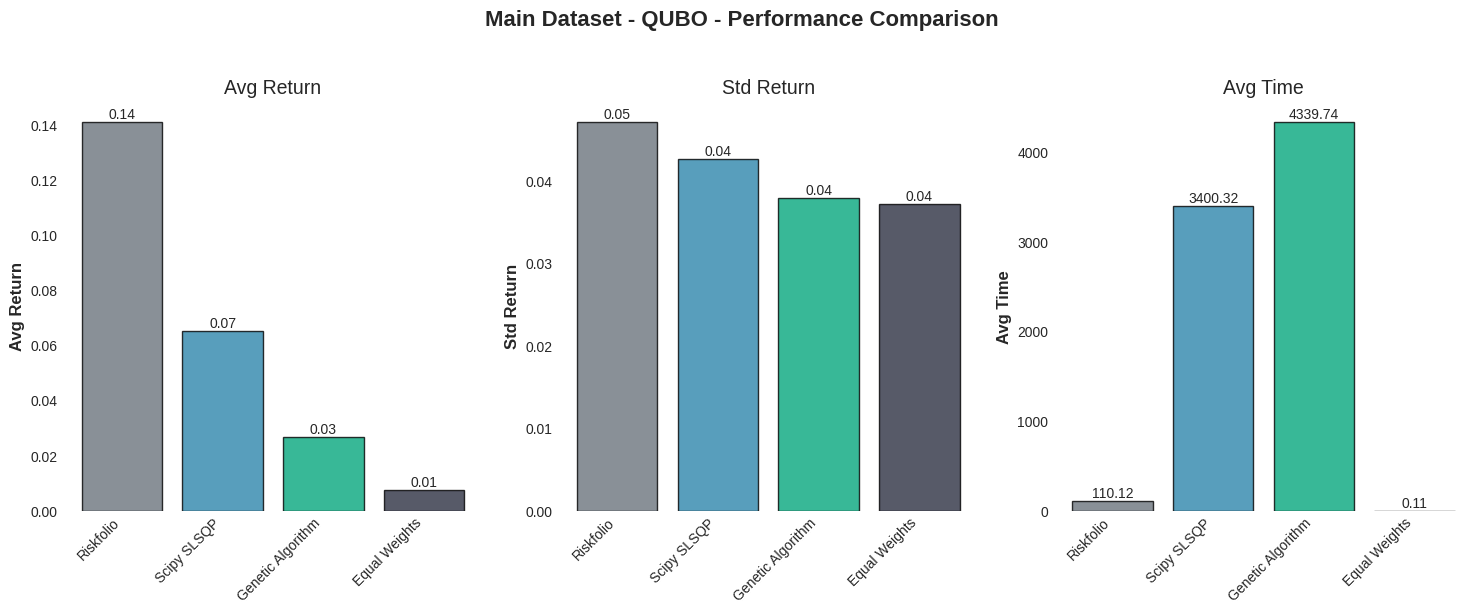

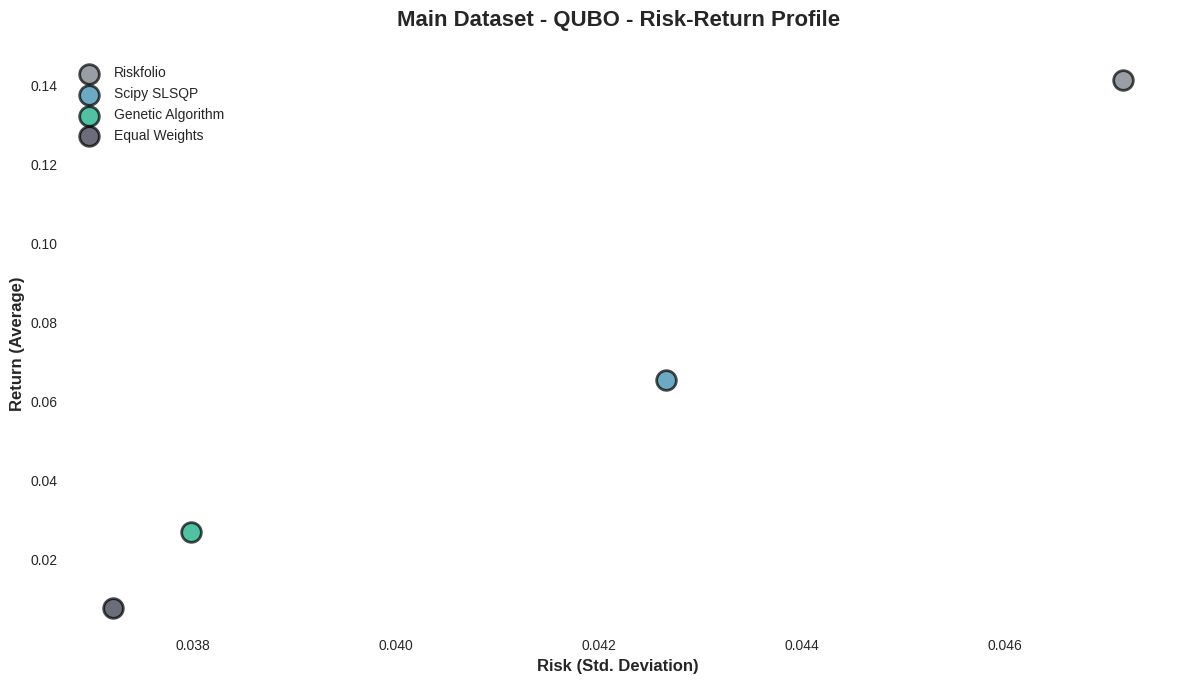


Main Dataset - QUBO - WEIGHT DISTRIBUTION ANALYSIS


/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:835: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:836: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


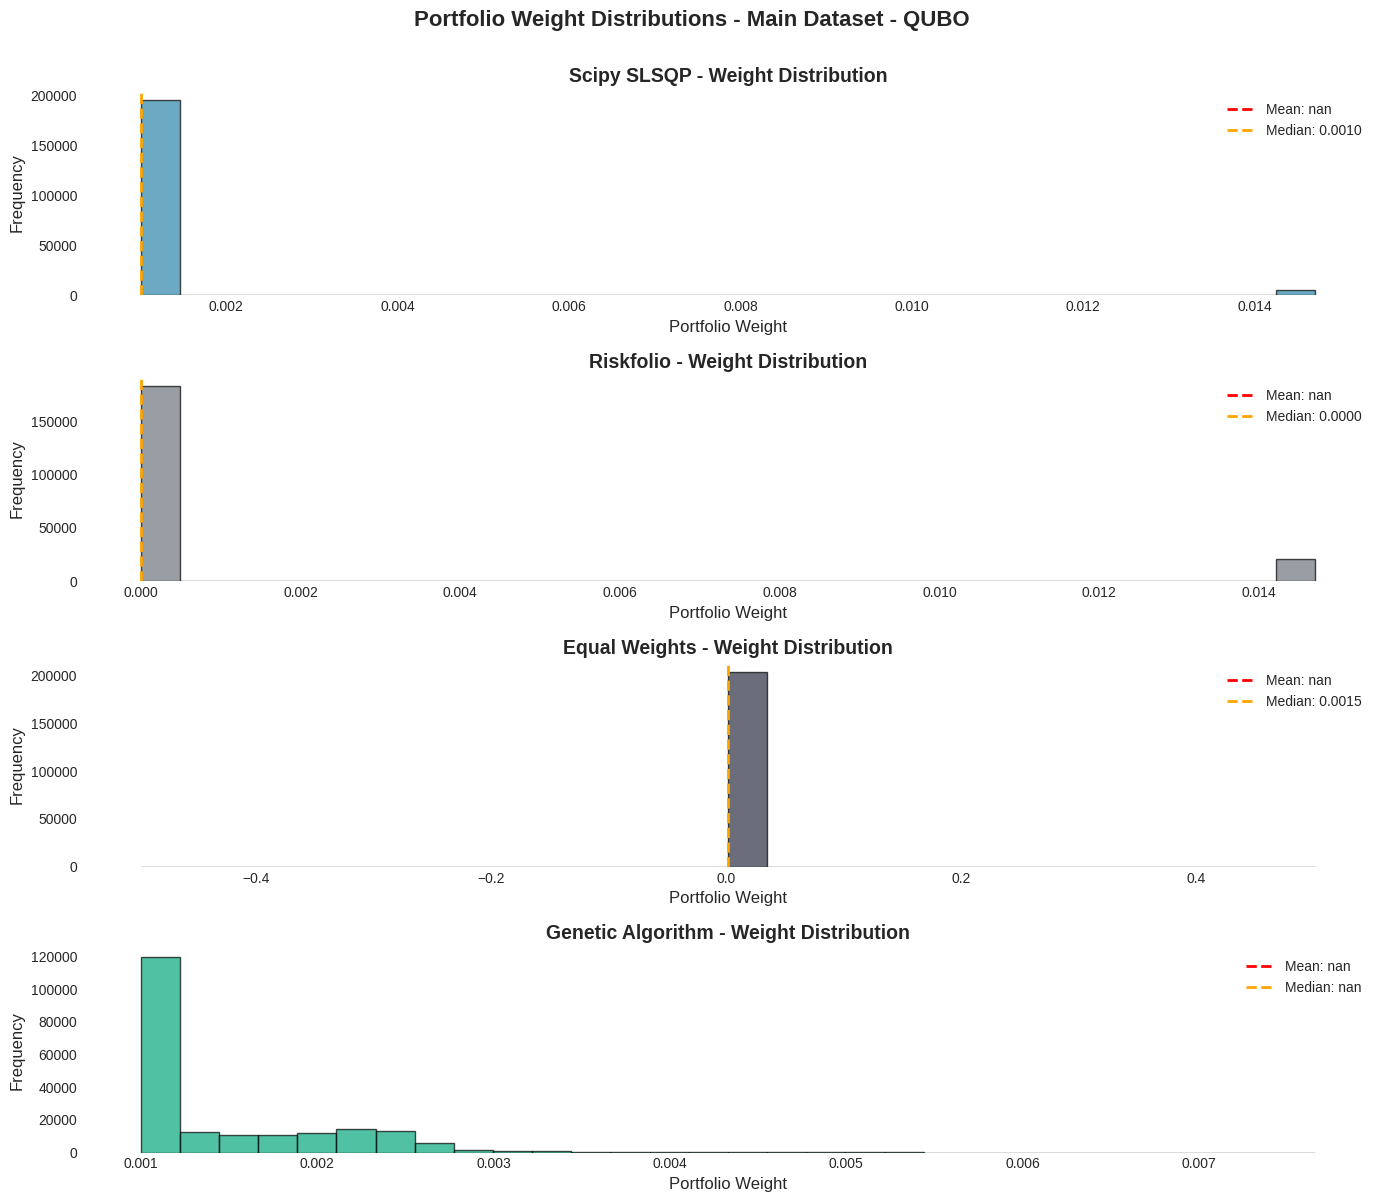


Main Dataset - Sharpe Optimization

MAIN DATASET - SHARPE OPTIMIZATION - COMPREHENSIVE ANALYSIS

Found 40 results for Main Dataset - Sharpe Optimization
Solvers: ['Equal Weights', 'Genetic Algorithm', 'Riskfolio', 'Scipy SLSQP']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Main Dataset - Sharpe Optimization - PERFORMANCE STATISTICS

Analyzing performance for Main Dataset - Sharpe Optimization...

           Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return    Avg_Time   Std_Time  Success_Rate
      Scipy SLSQP       10    0.055973    0.035796   -0.028704    0.102908 2411.137129 481.131511         100.0
Genetic Algorithm       10    0.025620    0.045338   -0.055127    0.082734 4358.000953   9.631542         100.0
        Riskfolio       10    0.007686    0.037216   -0.078645    0.054280   10.818991   0.758057         100.0
    Equal Weights       10    0.007686    0.037216   -0

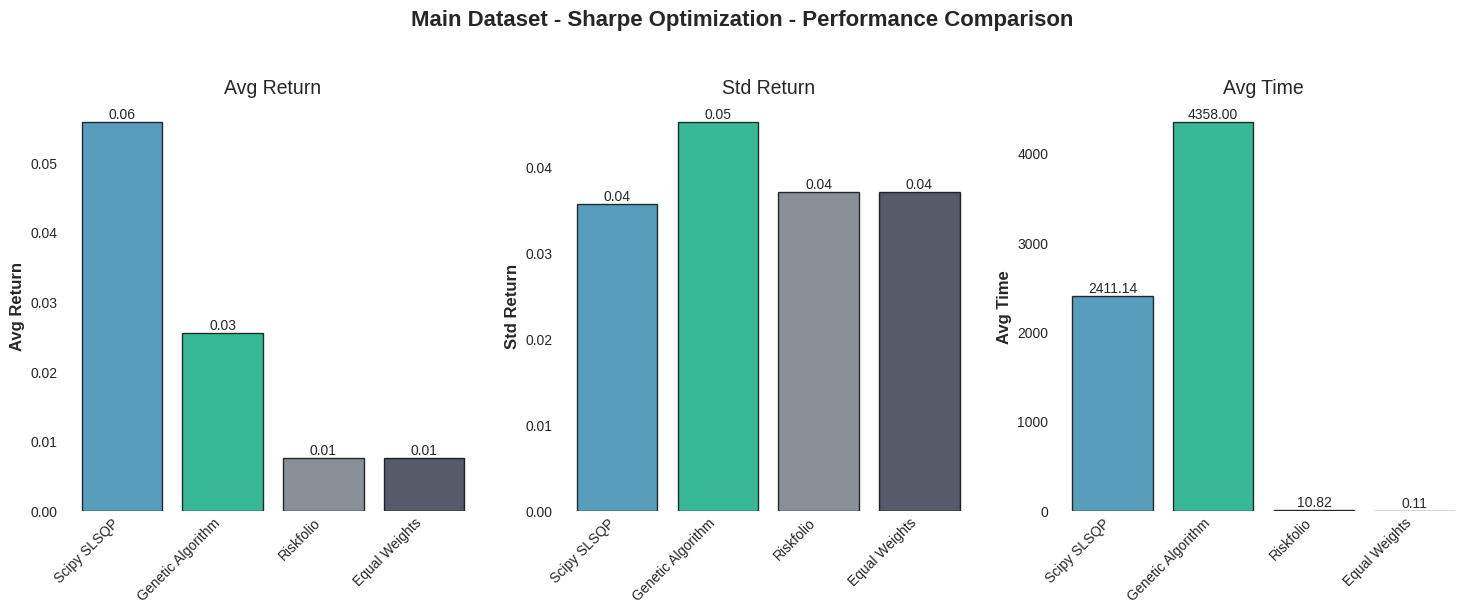

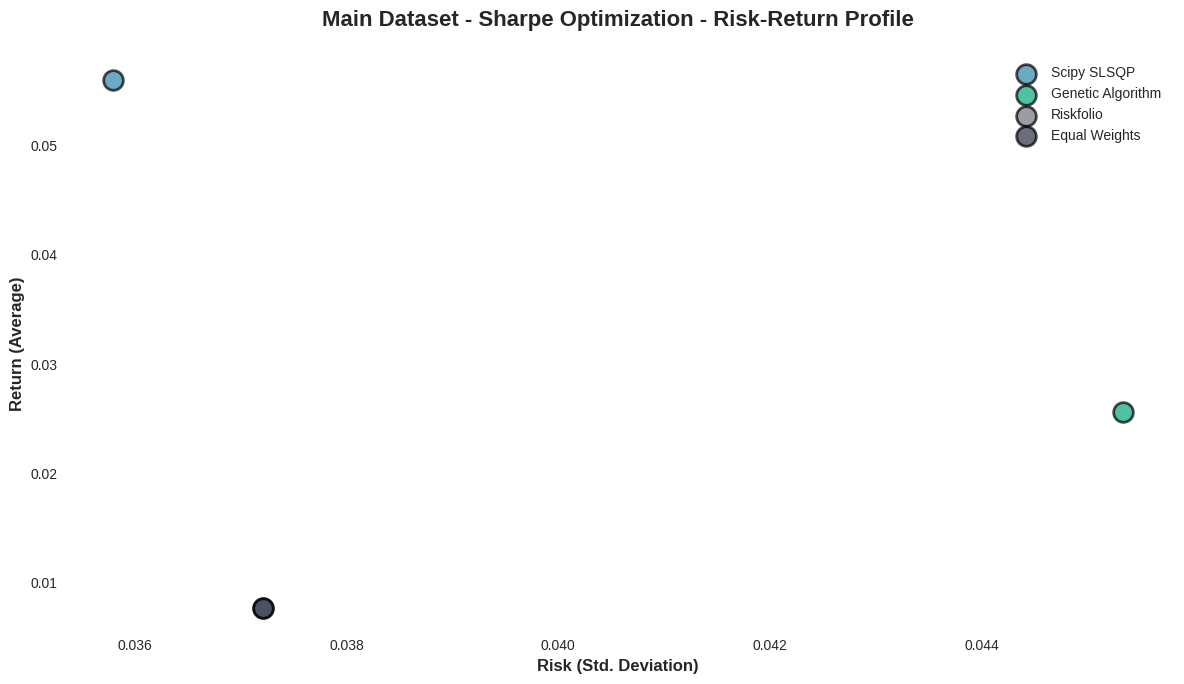


Main Dataset - Sharpe Optimization - WEIGHT DISTRIBUTION ANALYSIS


/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:835: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:836: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


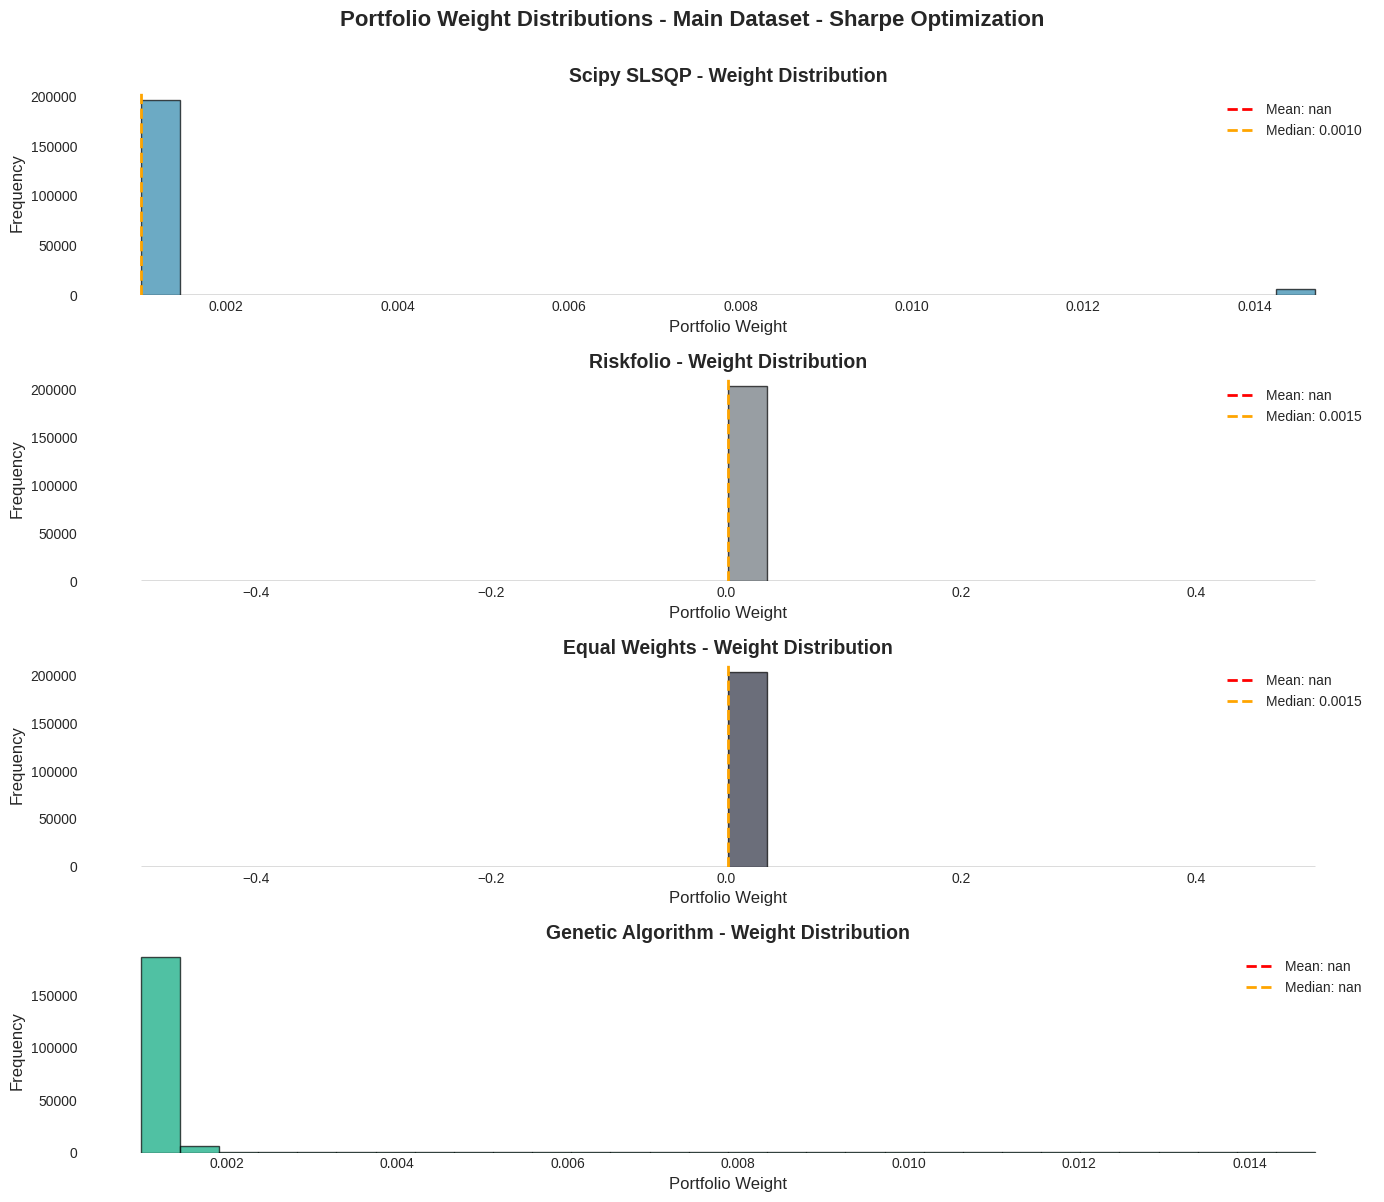

In [4]:
# Main dataset analysis
for method in ['QUBO', 'Sharpe Optimization']:
    stats = analyze_method_dataset(df_results, method, 'main', 'Main Dataset')
    if stats is not None:
        stats['Method'] = method
        stats['Dataset'] = 'Main Dataset'
        all_stats.append(stats)

### Synthetic Dataset


Synthetic Dataset - QUBO

SYNTHETIC DATASET - QUBO - COMPREHENSIVE ANALYSIS

Found 13 results for Synthetic Dataset - QUBO
Solvers: ['Equal Weights', 'Genetic Algorithm']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Synthetic Dataset - QUBO - PERFORMANCE STATISTICS

Analyzing performance for Synthetic Dataset - QUBO...

           Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return     Avg_Time  Std_Time  Success_Rate
Genetic Algorithm        3    0.082561    0.006536    0.078345    0.090089 12748.785131  6.413650         100.0
    Equal Weights       10    0.002062    0.031314   -0.062024    0.038860     0.116705  0.011649         100.0


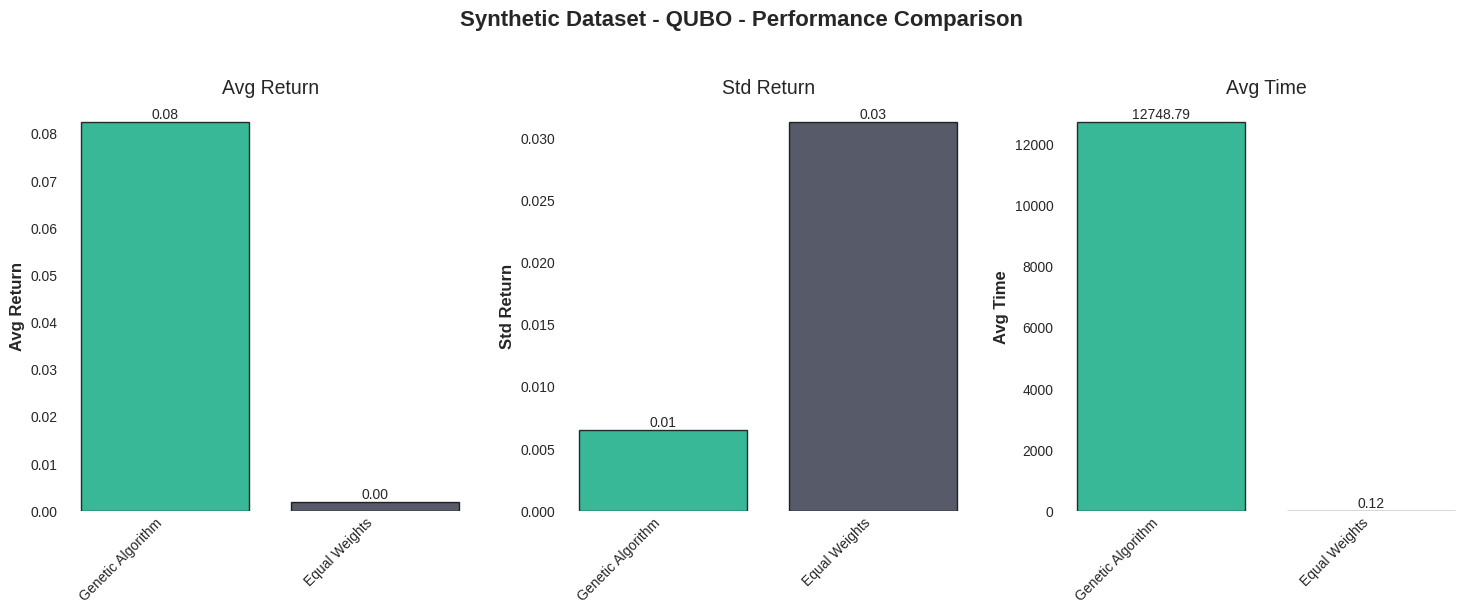

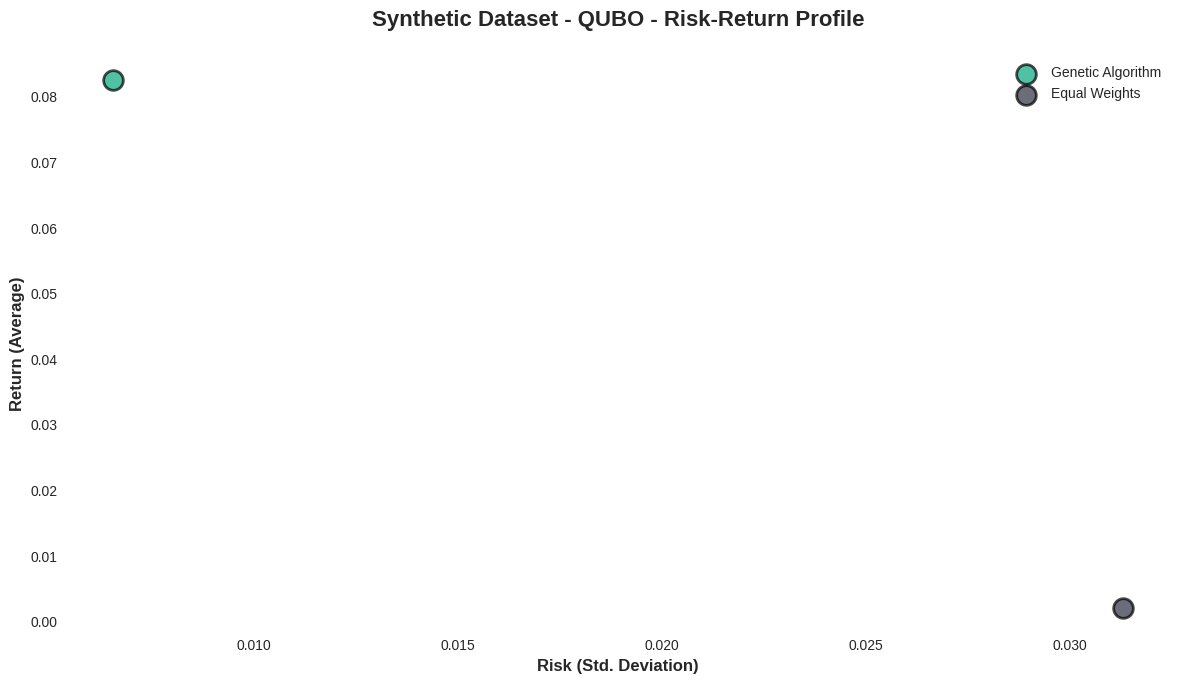


Synthetic Dataset - QUBO - WEIGHT DISTRIBUTION ANALYSIS


/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:835: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:836: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


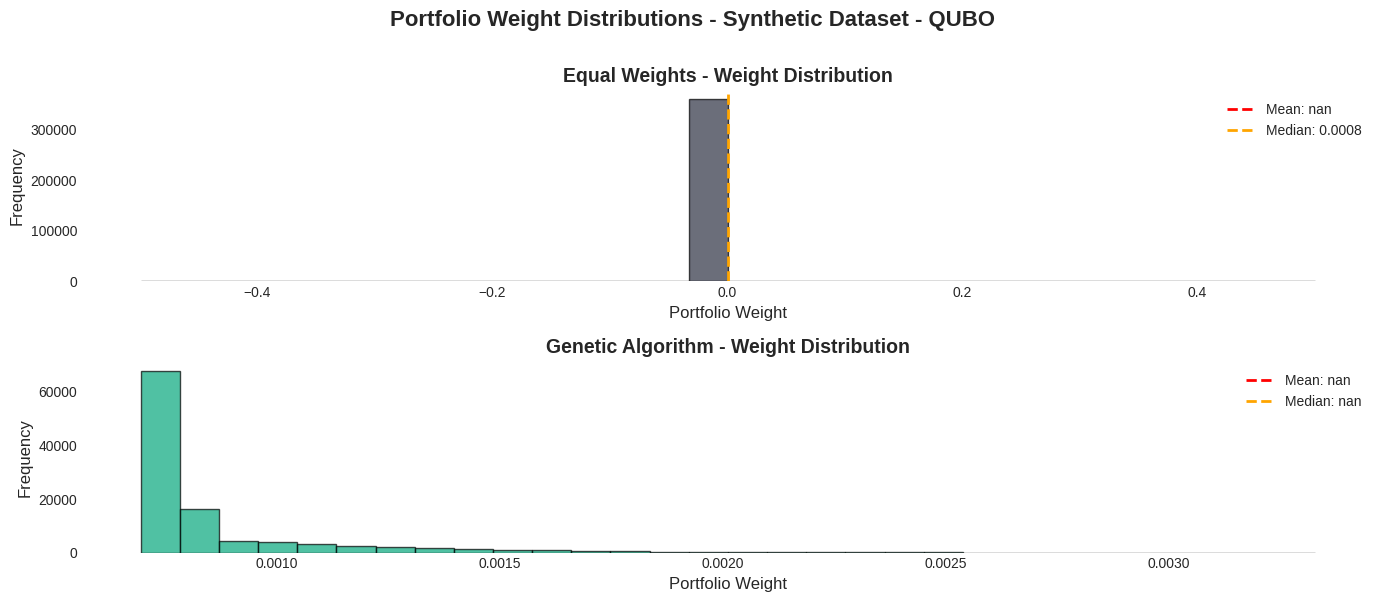


Synthetic Dataset - Sharpe Optimization

SYNTHETIC DATASET - SHARPE OPTIMIZATION - COMPREHENSIVE ANALYSIS

Found 10 results for Synthetic Dataset - Sharpe Optimization
Solvers: ['Equal Weights']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Synthetic Dataset - Sharpe Optimization - PERFORMANCE STATISTICS

Analyzing performance for Synthetic Dataset - Sharpe Optimization...

       Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return  Avg_Time  Std_Time  Success_Rate
Equal Weights       10    0.002062    0.031314   -0.062024     0.03886  0.117783  0.007306         100.0


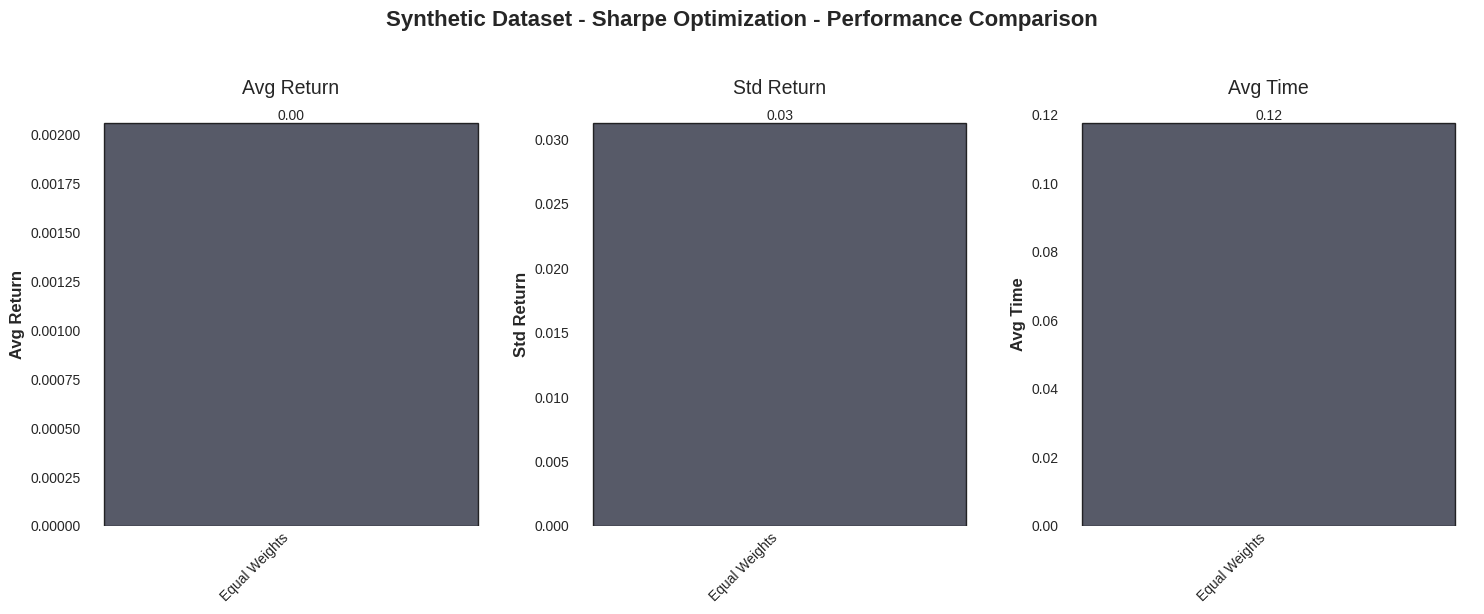

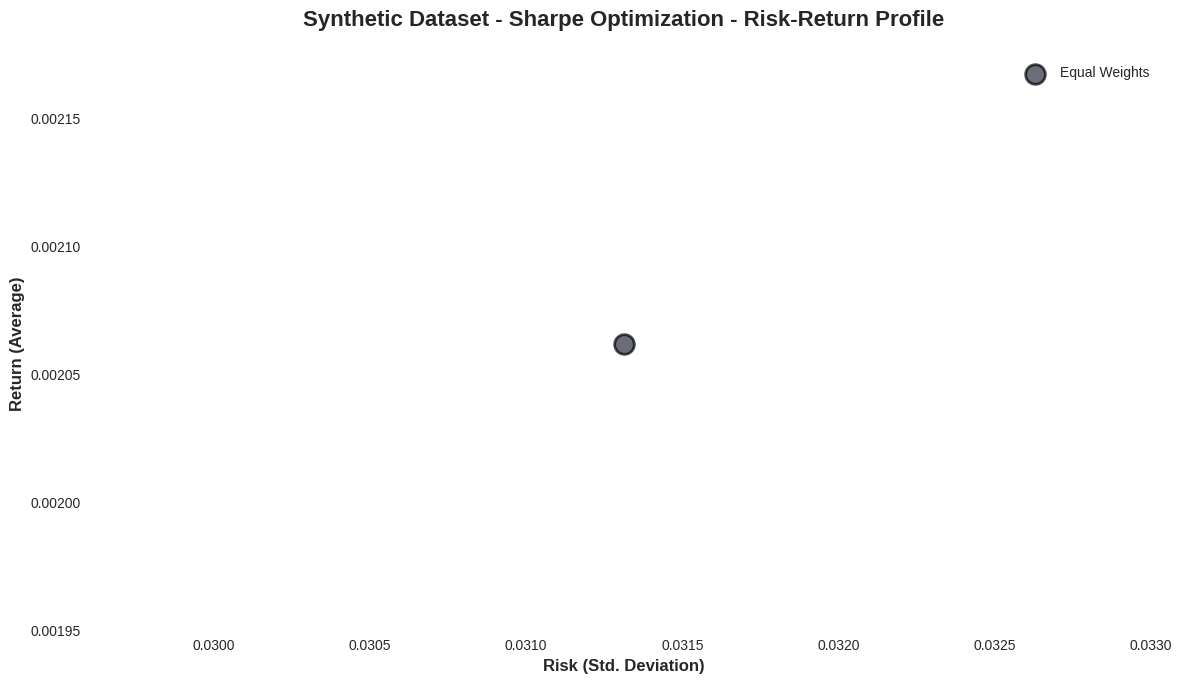


Synthetic Dataset - Sharpe Optimization - WEIGHT DISTRIBUTION ANALYSIS


/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:835: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:836: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


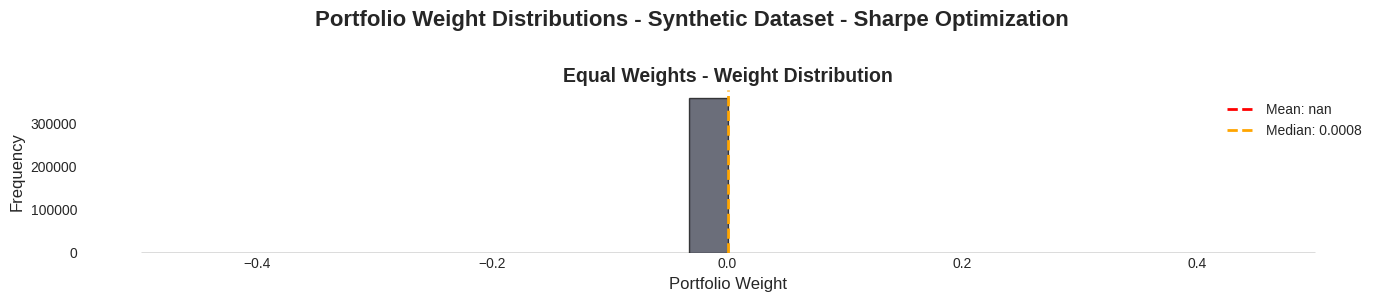

In [5]:
# Synthetic dataset analysis
for method in ['QUBO', 'Sharpe Optimization']:
    stats = analyze_method_dataset(df_results, method, 'synth', 'Synthetic Dataset')
    if stats is not None:
        stats['Method'] = method
        stats['Dataset'] = 'Synthetic'
        all_stats.append(stats)

### Legacy QUBO - All Datasets


10 Stocks - Legacy QUBO

10 STOCKS - LEGACY QUBO - COMPREHENSIVE ANALYSIS

Found 40 results for 10 Stocks - Legacy QUBO
Solvers: ['Equal Weights', 'Genetic Algorithm', 'Riskfolio', 'Scipy SLSQP']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

10 Stocks - Legacy QUBO - PERFORMANCE STATISTICS

Analyzing performance for 10 Stocks - Legacy QUBO...

           Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return  Avg_Time  Std_Time  Success_Rate
      Scipy SLSQP       10    0.260996    0.156439    0.065729    0.506859  1.904094  0.247043         100.0
        Riskfolio       10    0.260518    0.147083    0.068373    0.450439  0.516529  0.049545         100.0
Genetic Algorithm       10    0.209495    0.145788    0.048572    0.484237 73.922659  0.255483         100.0
    Equal Weights       10    0.043195    0.062592   -0.061880    0.121450  0.083816  0.032473         100.0


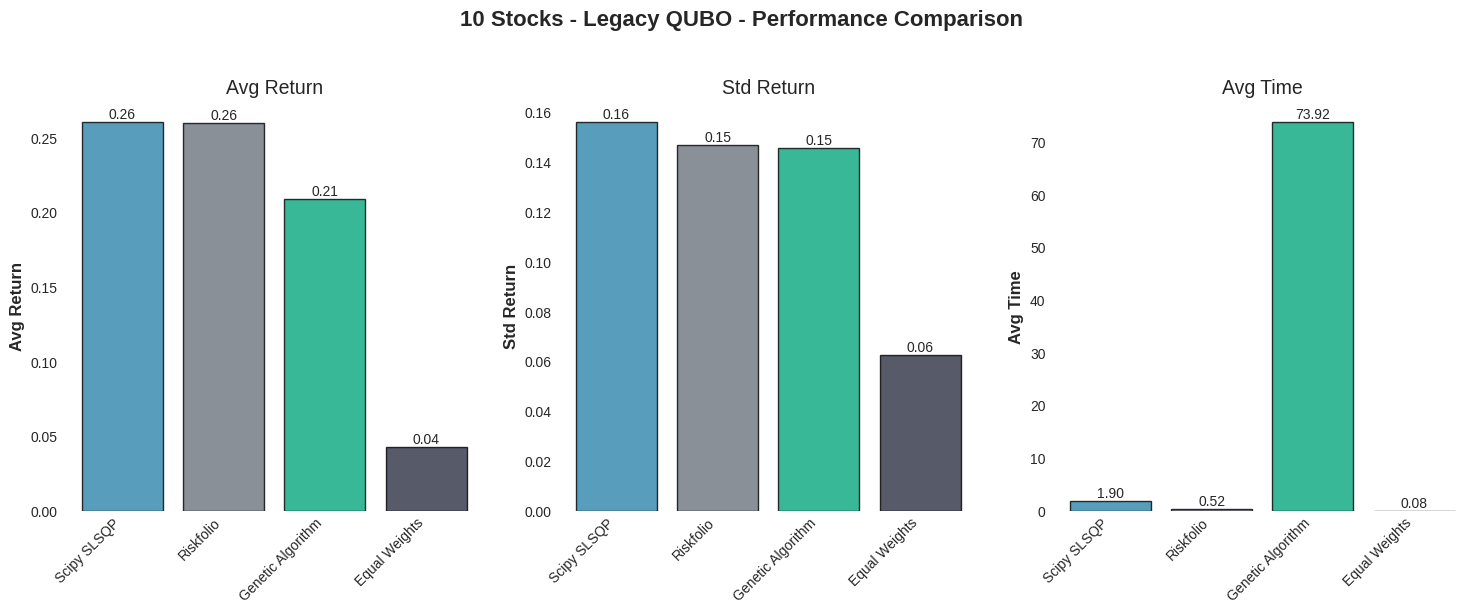

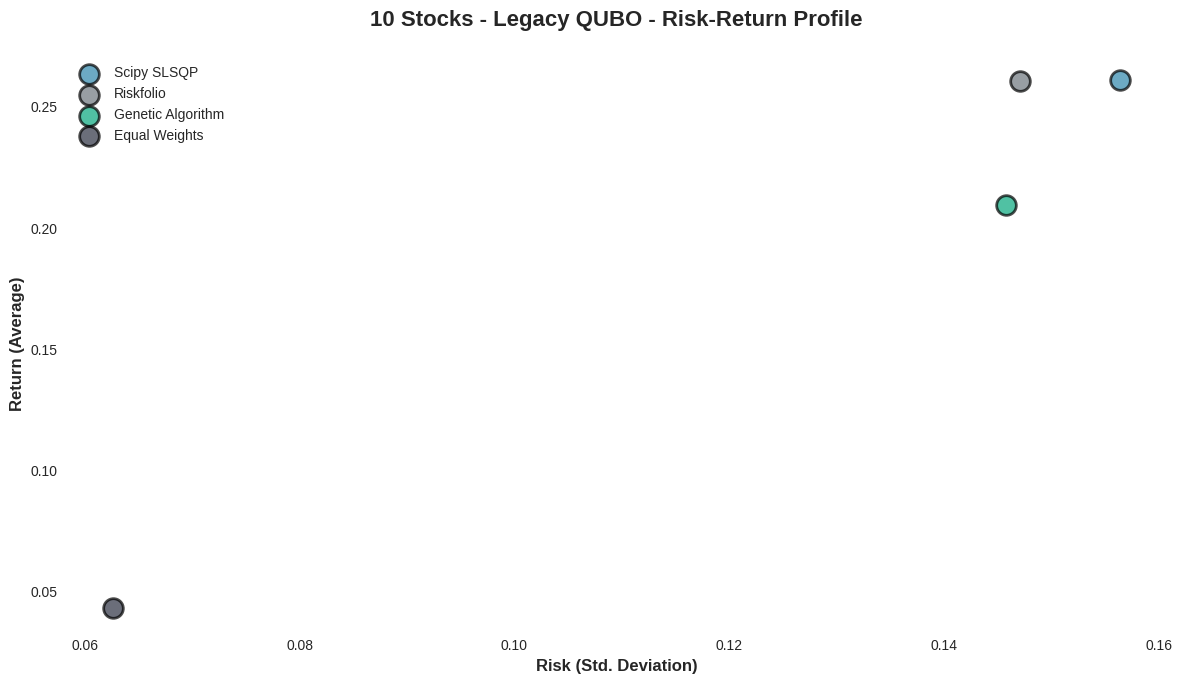


10 Stocks - Legacy QUBO - WEIGHT DISTRIBUTION ANALYSIS


/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:835: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:836: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


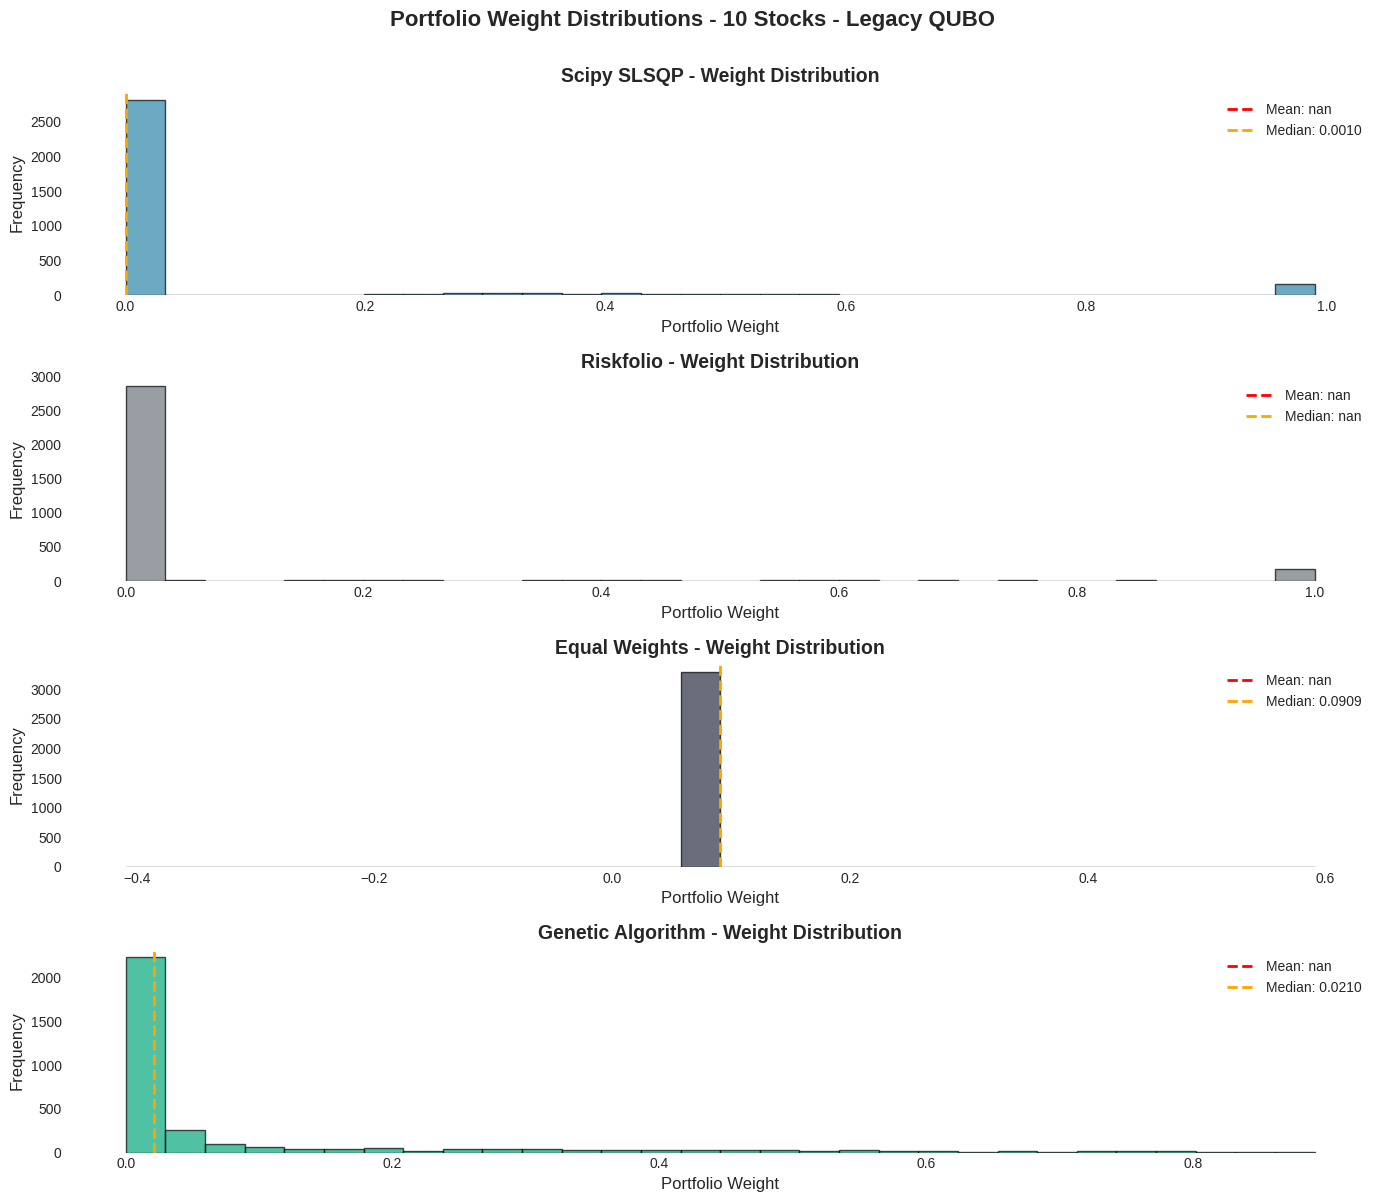


100 Stocks - Legacy QUBO

100 STOCKS - LEGACY QUBO - COMPREHENSIVE ANALYSIS

Found 40 results for 100 Stocks - Legacy QUBO
Solvers: ['Equal Weights', 'Genetic Algorithm', 'Riskfolio', 'Scipy SLSQP']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

100 Stocks - Legacy QUBO - PERFORMANCE STATISTICS

Analyzing performance for 100 Stocks - Legacy QUBO...

           Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return   Avg_Time  Std_Time  Success_Rate
        Riskfolio       10    0.319771    0.133805    0.116417    0.517431   2.526699  0.101919         100.0
      Scipy SLSQP       10    0.295275    0.133909    0.114973    0.513792  45.834771  7.574188         100.0
Genetic Algorithm       10    0.126425    0.072779    0.037287    0.286158 166.415861  4.918976         100.0
    Equal Weights       10    0.036126    0.043258   -0.027865    0.094331   0.074614  0.002052         100.0


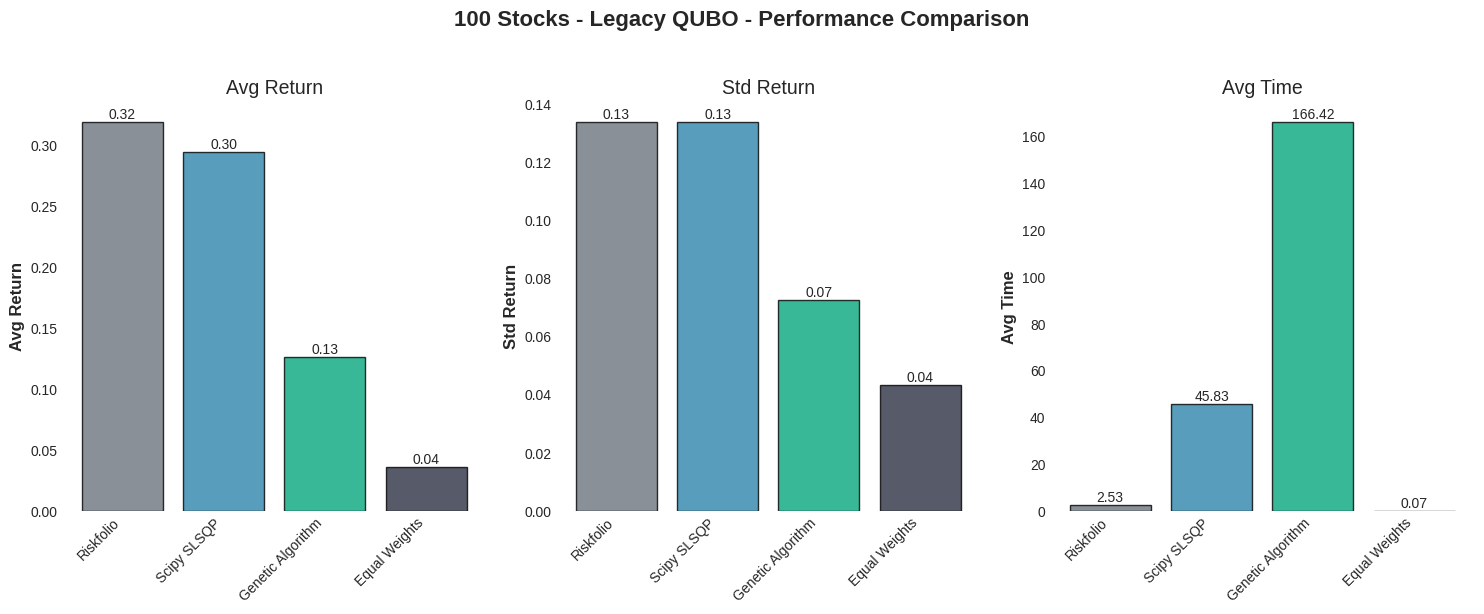

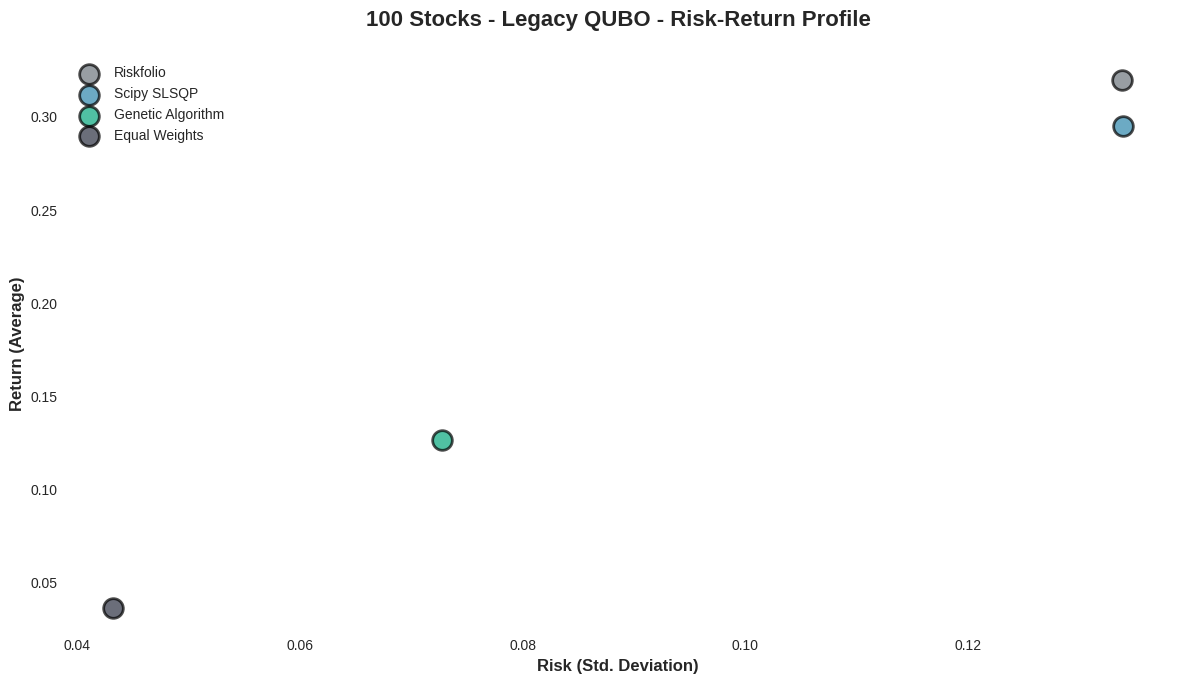


100 Stocks - Legacy QUBO - WEIGHT DISTRIBUTION ANALYSIS


/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:835: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:836: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


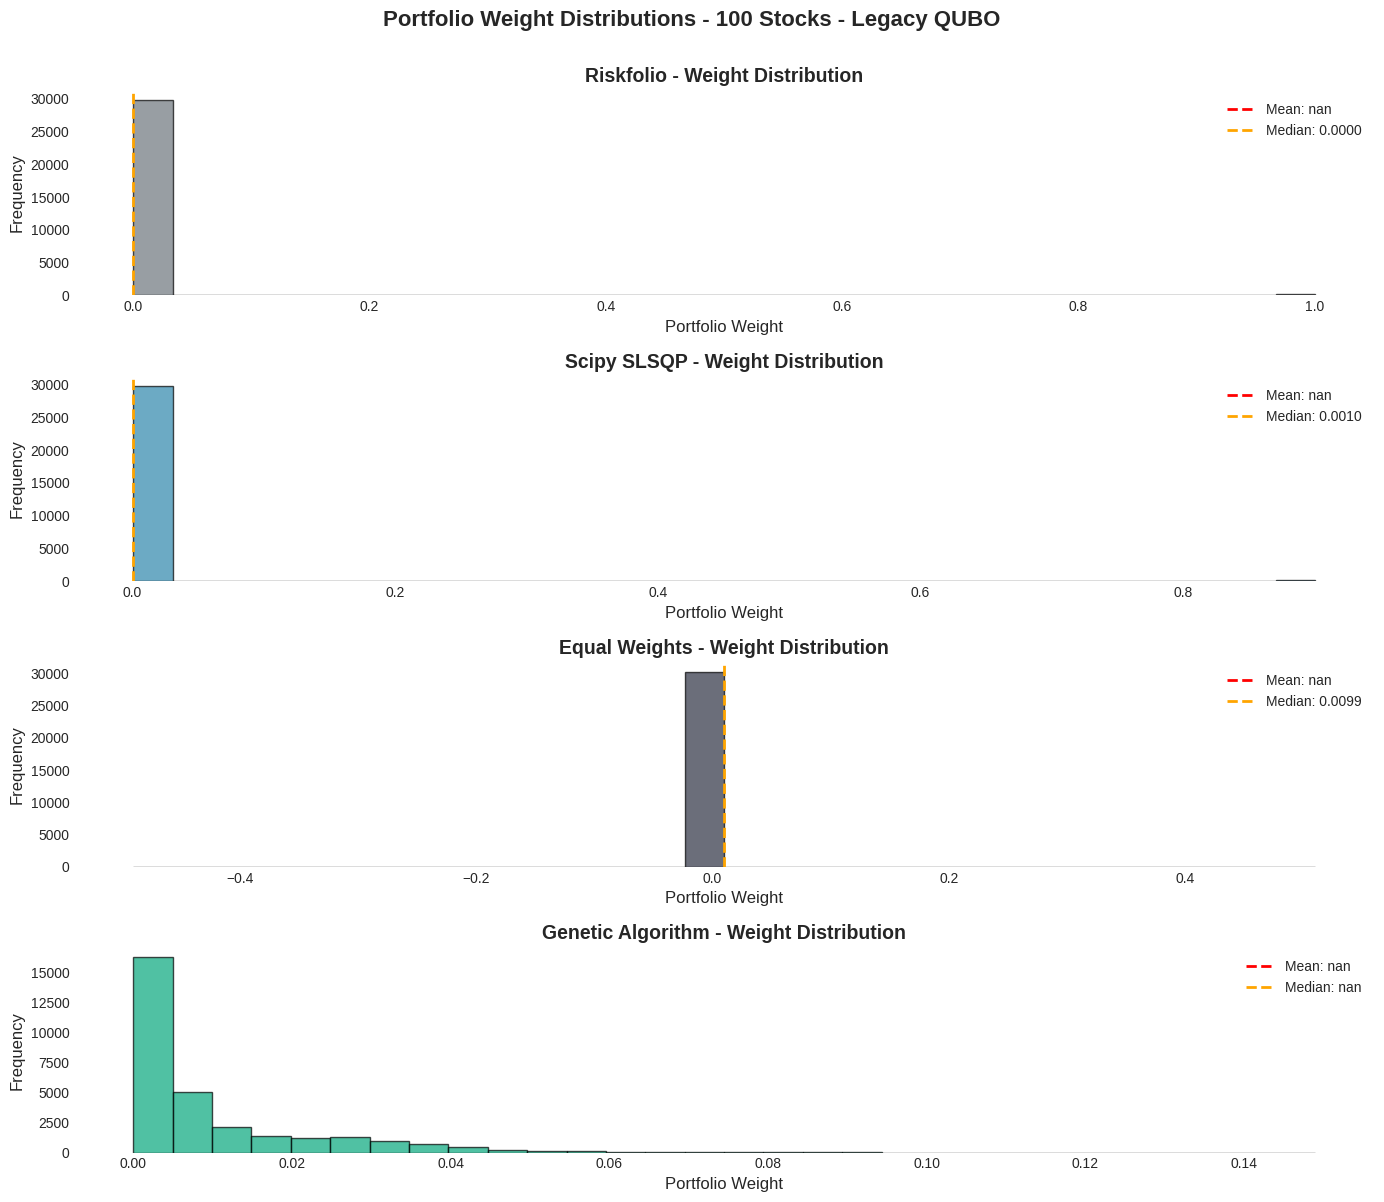


439 Stocks - Legacy QUBO

439 STOCKS - LEGACY QUBO - COMPREHENSIVE ANALYSIS

Found 50 results for 439 Stocks - Legacy QUBO
Solvers: ['D-Wave CQM', 'Equal Weights', 'Genetic Algorithm', 'Riskfolio', 'Scipy SLSQP']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

439 Stocks - Legacy QUBO - PERFORMANCE STATISTICS

Analyzing performance for 439 Stocks - Legacy QUBO...

           Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return    Avg_Time   Std_Time  Success_Rate
        Riskfolio       10    0.326283    0.185313    0.136920    0.622888   32.856497   1.212175         100.0
      Scipy SLSQP       10    0.219370    0.137066    0.075699    0.461197 1737.847789 273.625496         100.0
Genetic Algorithm       10    0.077606    0.046827    0.021712    0.158042 1831.975170   2.283231         100.0
    Equal Weights       10    0.028768    0.036209   -0.022137    0.083623    0.090100   0.

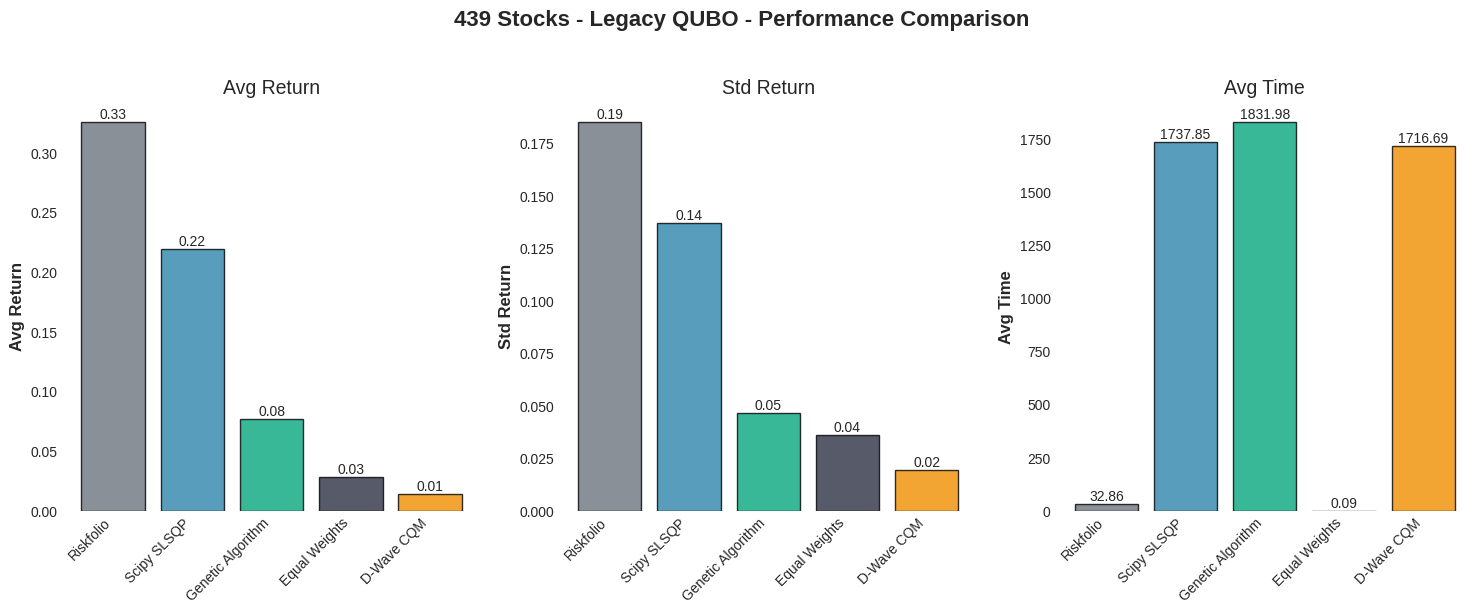

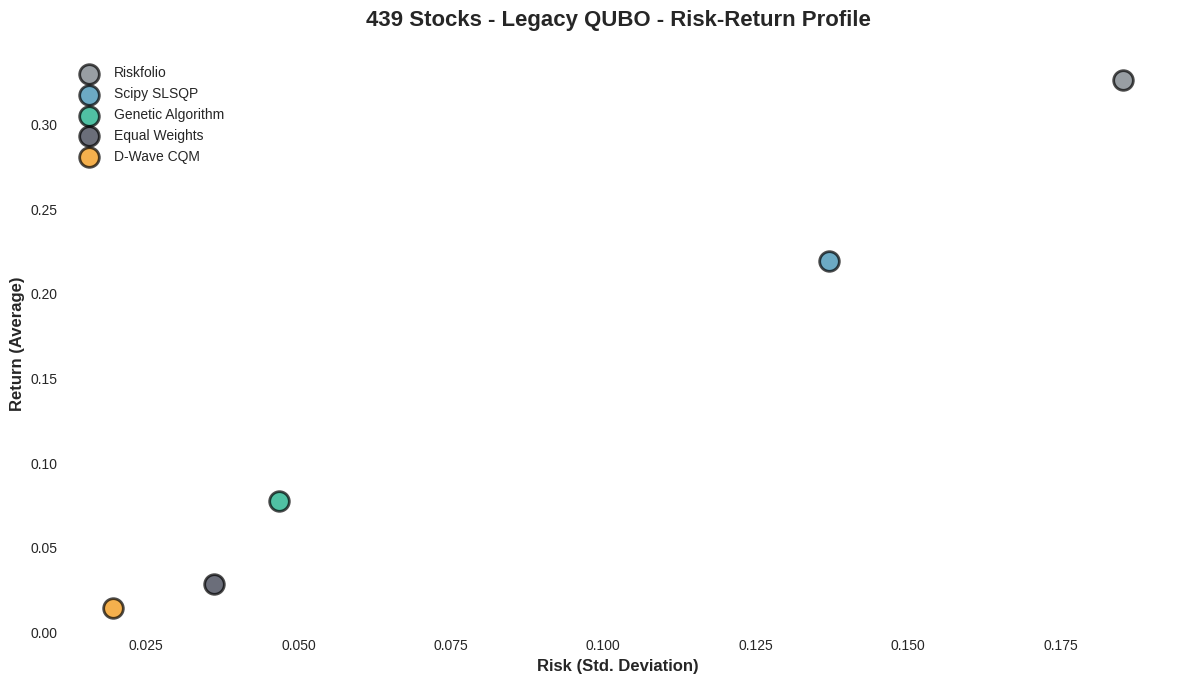


439 Stocks - Legacy QUBO - WEIGHT DISTRIBUTION ANALYSIS


/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:835: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:836: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


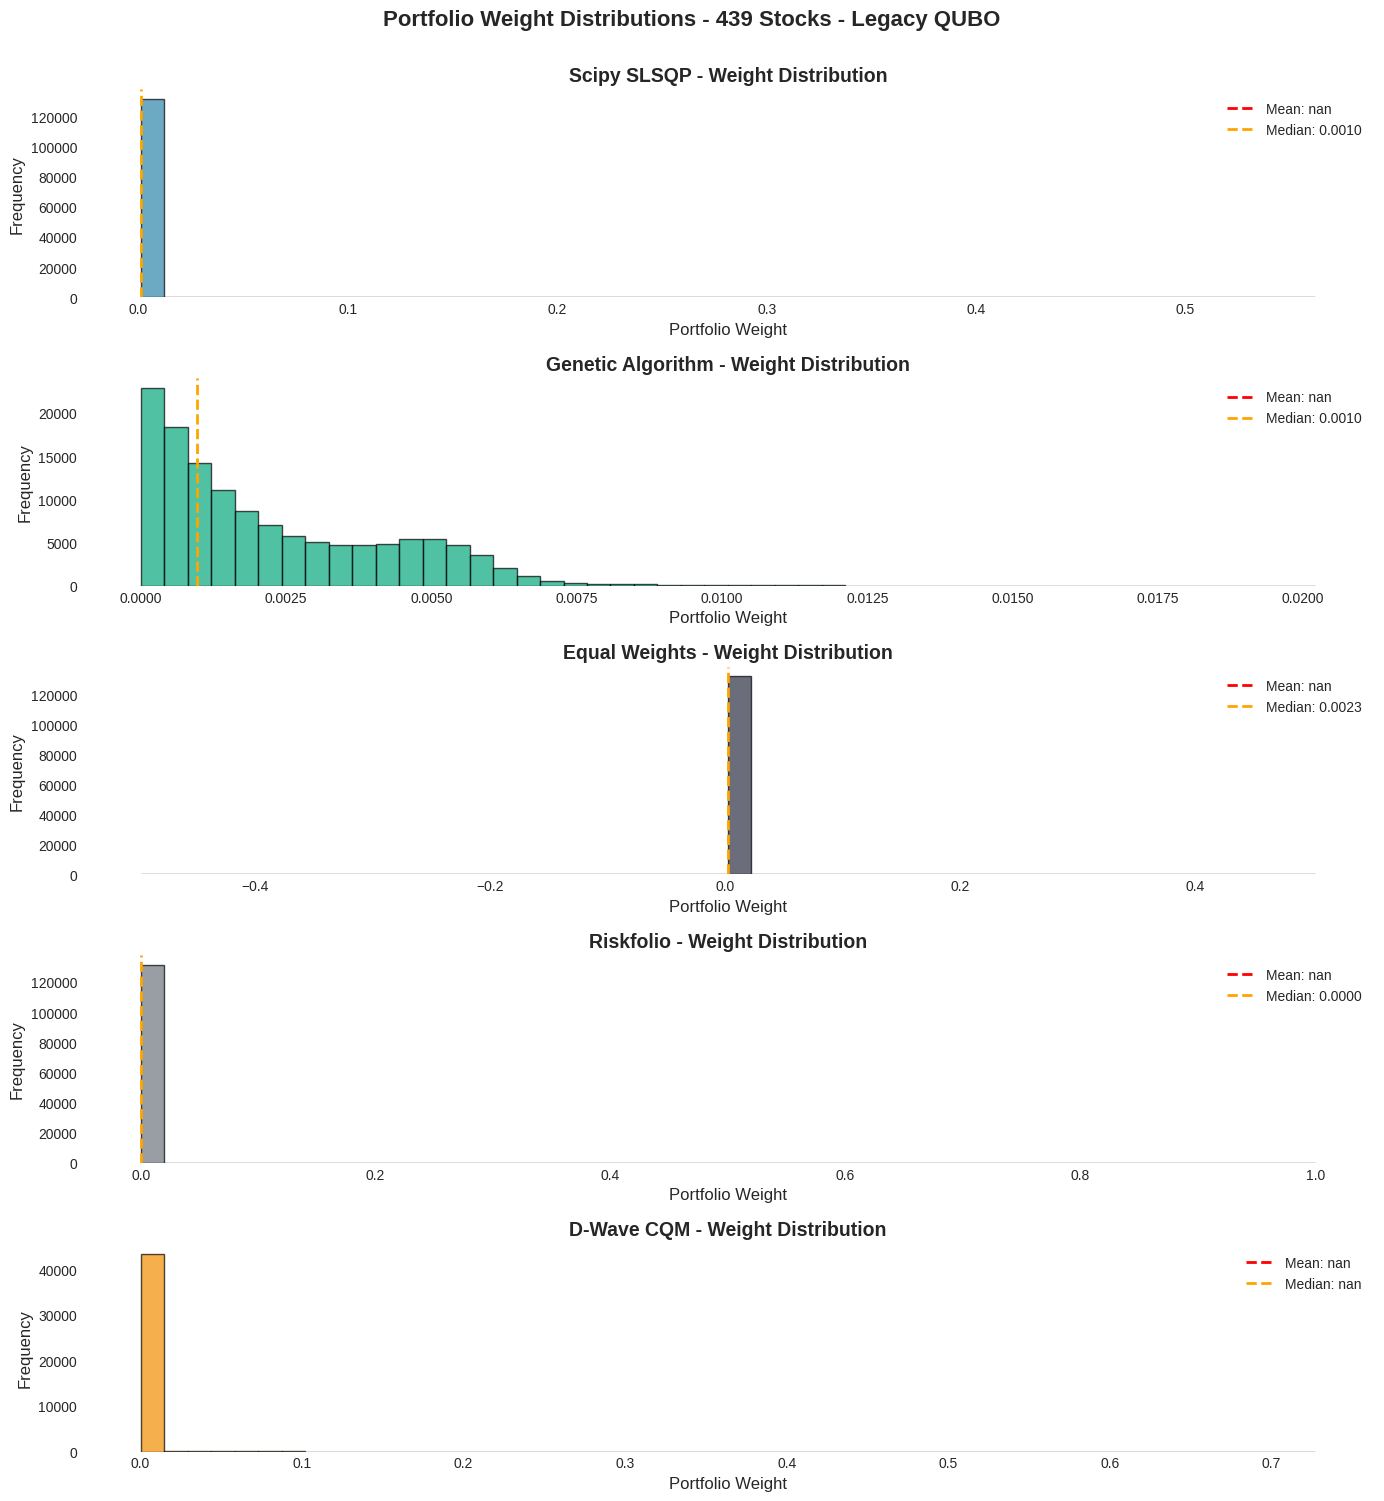


680 Assets - Legacy QUBO

680 ASSETS - LEGACY QUBO - COMPREHENSIVE ANALYSIS

Found 50 results for 680 Assets - Legacy QUBO
Solvers: ['D-Wave CQM', 'Equal Weights', 'Genetic Algorithm', 'Riskfolio', 'Scipy SLSQP']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

680 Assets - Legacy QUBO - PERFORMANCE STATISTICS

Analyzing performance for 680 Assets - Legacy QUBO...

           Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return    Avg_Time   Std_Time  Success_Rate
      Scipy SLSQP       10    0.180130    0.245560    0.020156    0.868911 5354.728797 752.748472         100.0
        Riskfolio       10    0.071855    0.195376   -0.078645    0.618592   29.526356  16.606512         100.0
Genetic Algorithm       10    0.047508    0.039315   -0.047946    0.096569 4183.915608   4.396421         100.0
    Equal Weights       10    0.007686    0.037216   -0.078645    0.054280    0.103905   0.

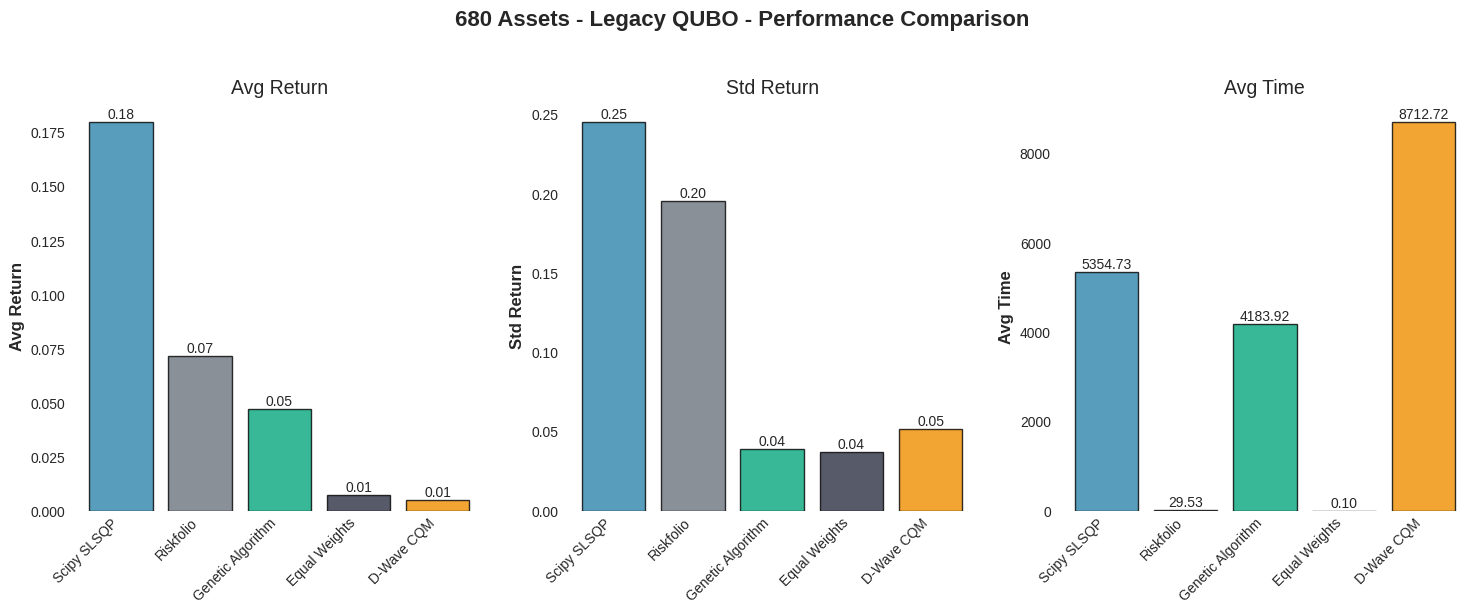

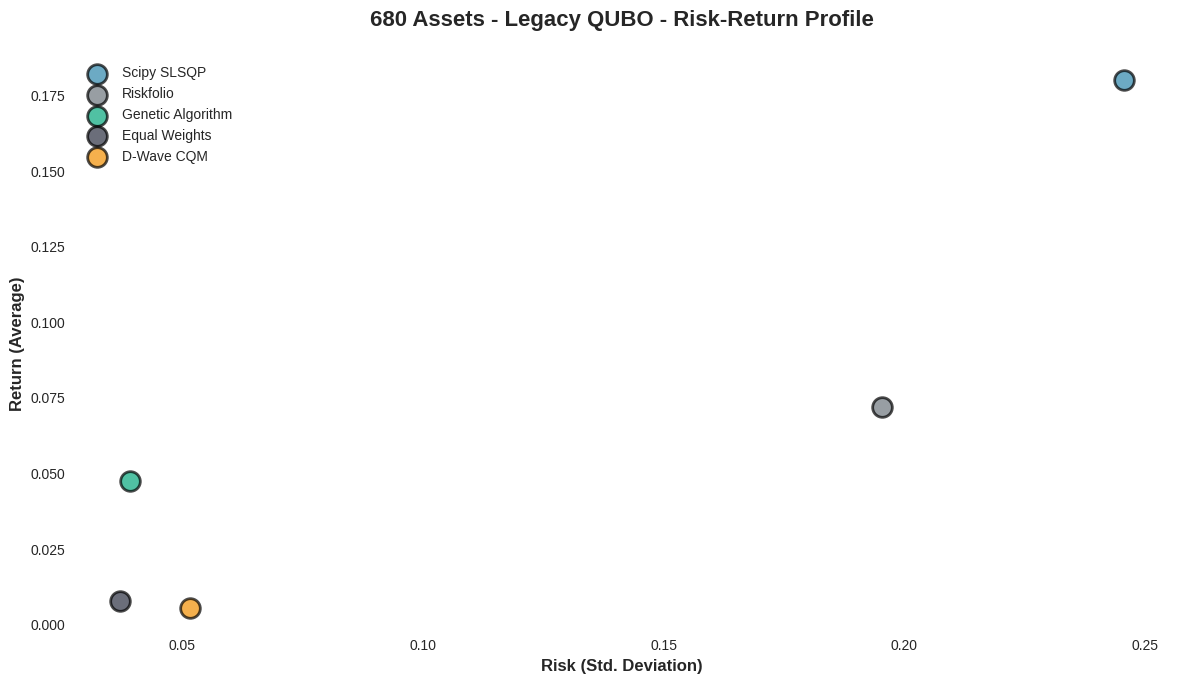


680 Assets - Legacy QUBO - WEIGHT DISTRIBUTION ANALYSIS


/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:835: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/bmartins/anaconda3/envs/qportfolio3/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:836: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


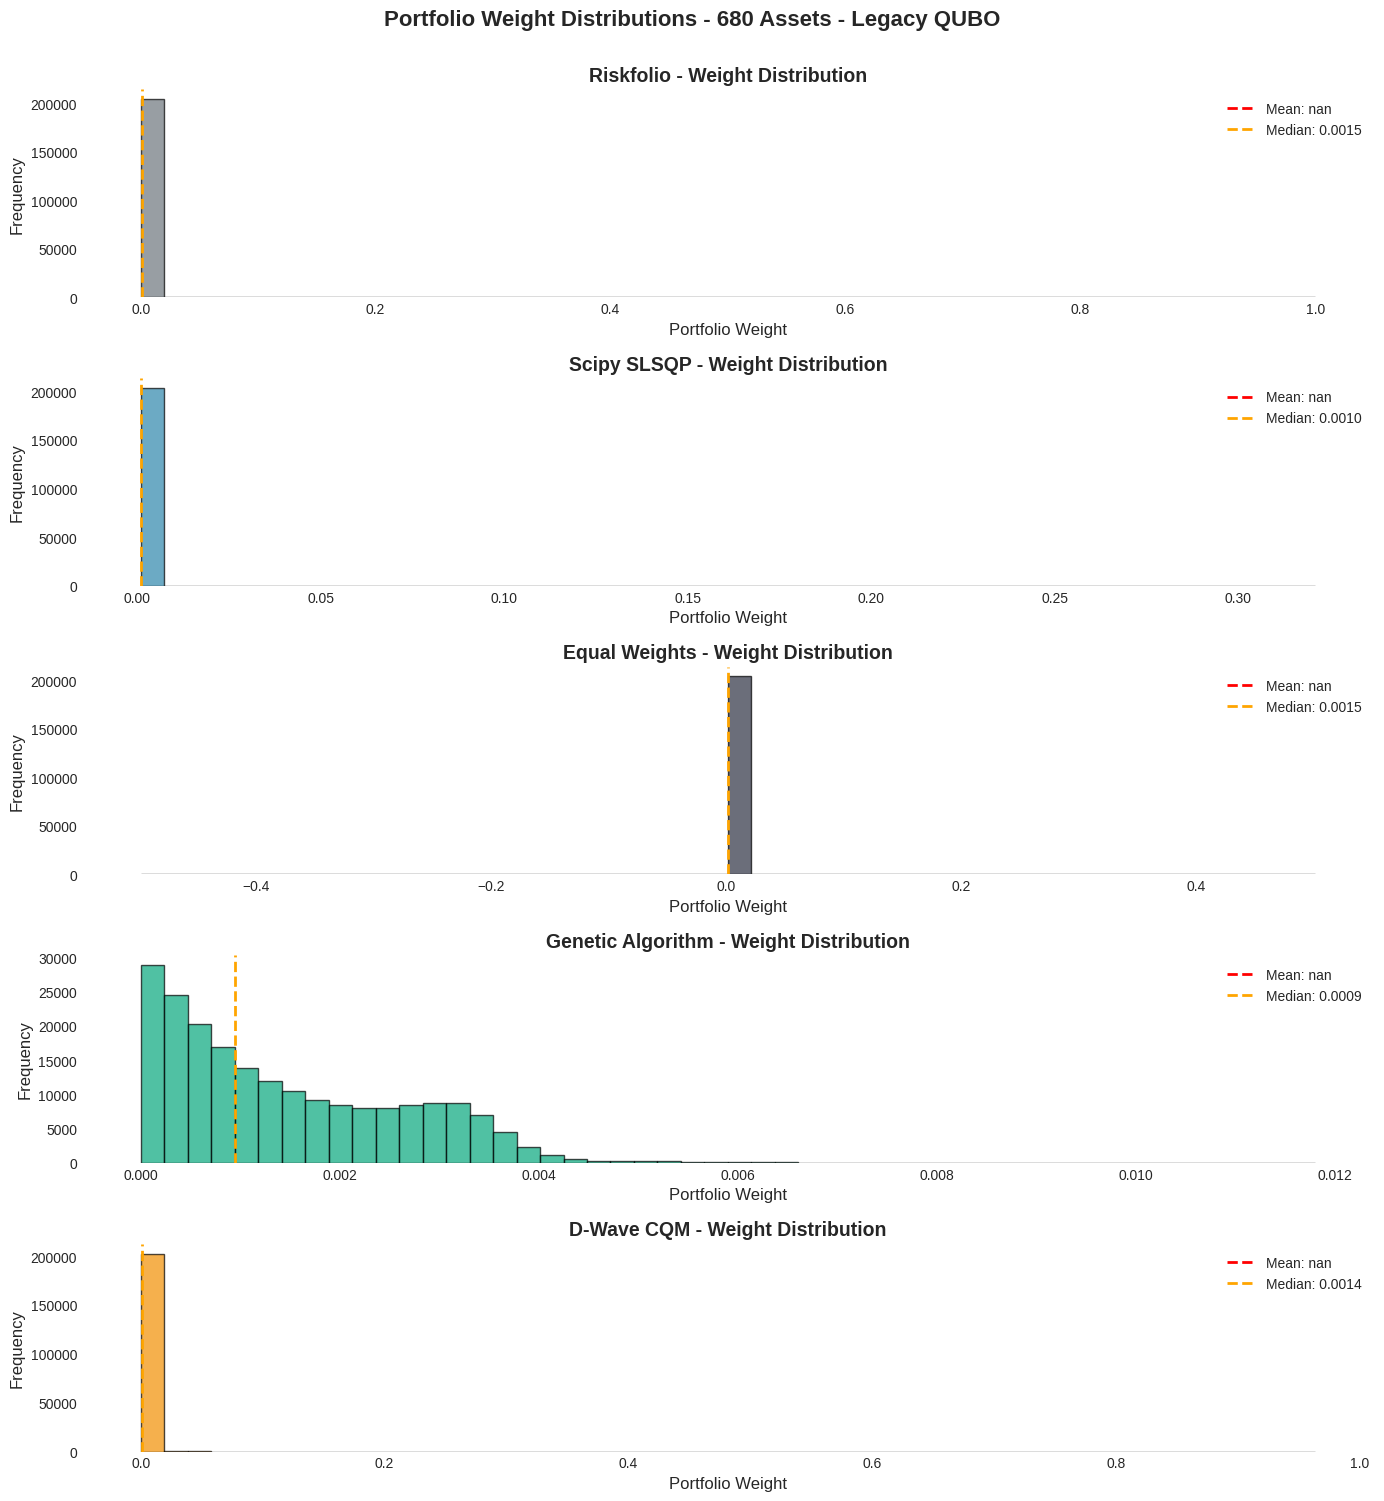

In [6]:
# Legacy QUBO analysis for all datasets
for dataset, dataset_name in [('10', '10 Stocks'), ('100', '100 Stocks'), ('full', '439 Stocks'), ('wide', '680 Assets')]:
    stats = analyze_method_dataset(df_results, 'Legacy QUBO', dataset, dataset_name)
    if stats is not None:
        stats['Method'] = 'Legacy QUBO'
        stats['Dataset'] = dataset_name
        all_stats.append(stats)

## Cross-Method Comparison

Compare performance across all methods and datasets.

In [7]:
print("\n" + "=" * 100)
print("CROSS-METHOD PERFORMANCE COMPARISON")
print("=" * 100)

if all_stats:
    df_all_stats = pd.concat(all_stats, ignore_index=True)
    
    # Pivot for comparison
    print("\n" + "="*80)
    print("AVERAGE RETURN BY DATASET AND METHOD")
    print("="*80)
    pivot_return = df_all_stats.pivot_table(values='Avg_Return', index=['Dataset', 'Solver'], columns='Method')
    print(pivot_return.to_string())
    
    print("\n" + "="*80)
    print("AVERAGE EXECUTION TIME BY DATASET AND METHOD")
    print("="*80)
    pivot_time = df_all_stats.pivot_table(values='Avg_Time', index=['Dataset', 'Solver'], columns='Method')
    print(pivot_time.to_string())
    
    print("\n" + "="*80)
    print("RISK (STD DEVIATION) BY DATASET AND METHOD")
    print("="*80)
    pivot_risk = df_all_stats.pivot_table(values='Std_Return', index=['Dataset', 'Solver'], columns='Method')
    print(pivot_risk.to_string())


CROSS-METHOD PERFORMANCE COMPARISON

AVERAGE RETURN BY DATASET AND METHOD
Method                          Legacy QUBO      QUBO  Sharpe Optimization
Dataset      Solver                                                       
10 Stocks    Equal Weights         0.043195       NaN                  NaN
             Genetic Algorithm     0.209495       NaN                  NaN
             Riskfolio             0.260518       NaN                  NaN
             Scipy SLSQP           0.260996       NaN                  NaN
100 Stocks   Equal Weights         0.036126       NaN                  NaN
             Genetic Algorithm     0.126425       NaN                  NaN
             Riskfolio             0.319771       NaN                  NaN
             Scipy SLSQP           0.295275       NaN                  NaN
439 Stocks   D-Wave CQM            0.014390       NaN                  NaN
             Equal Weights         0.028768       NaN                  NaN
             Genetic Algo

## Visual Comparison

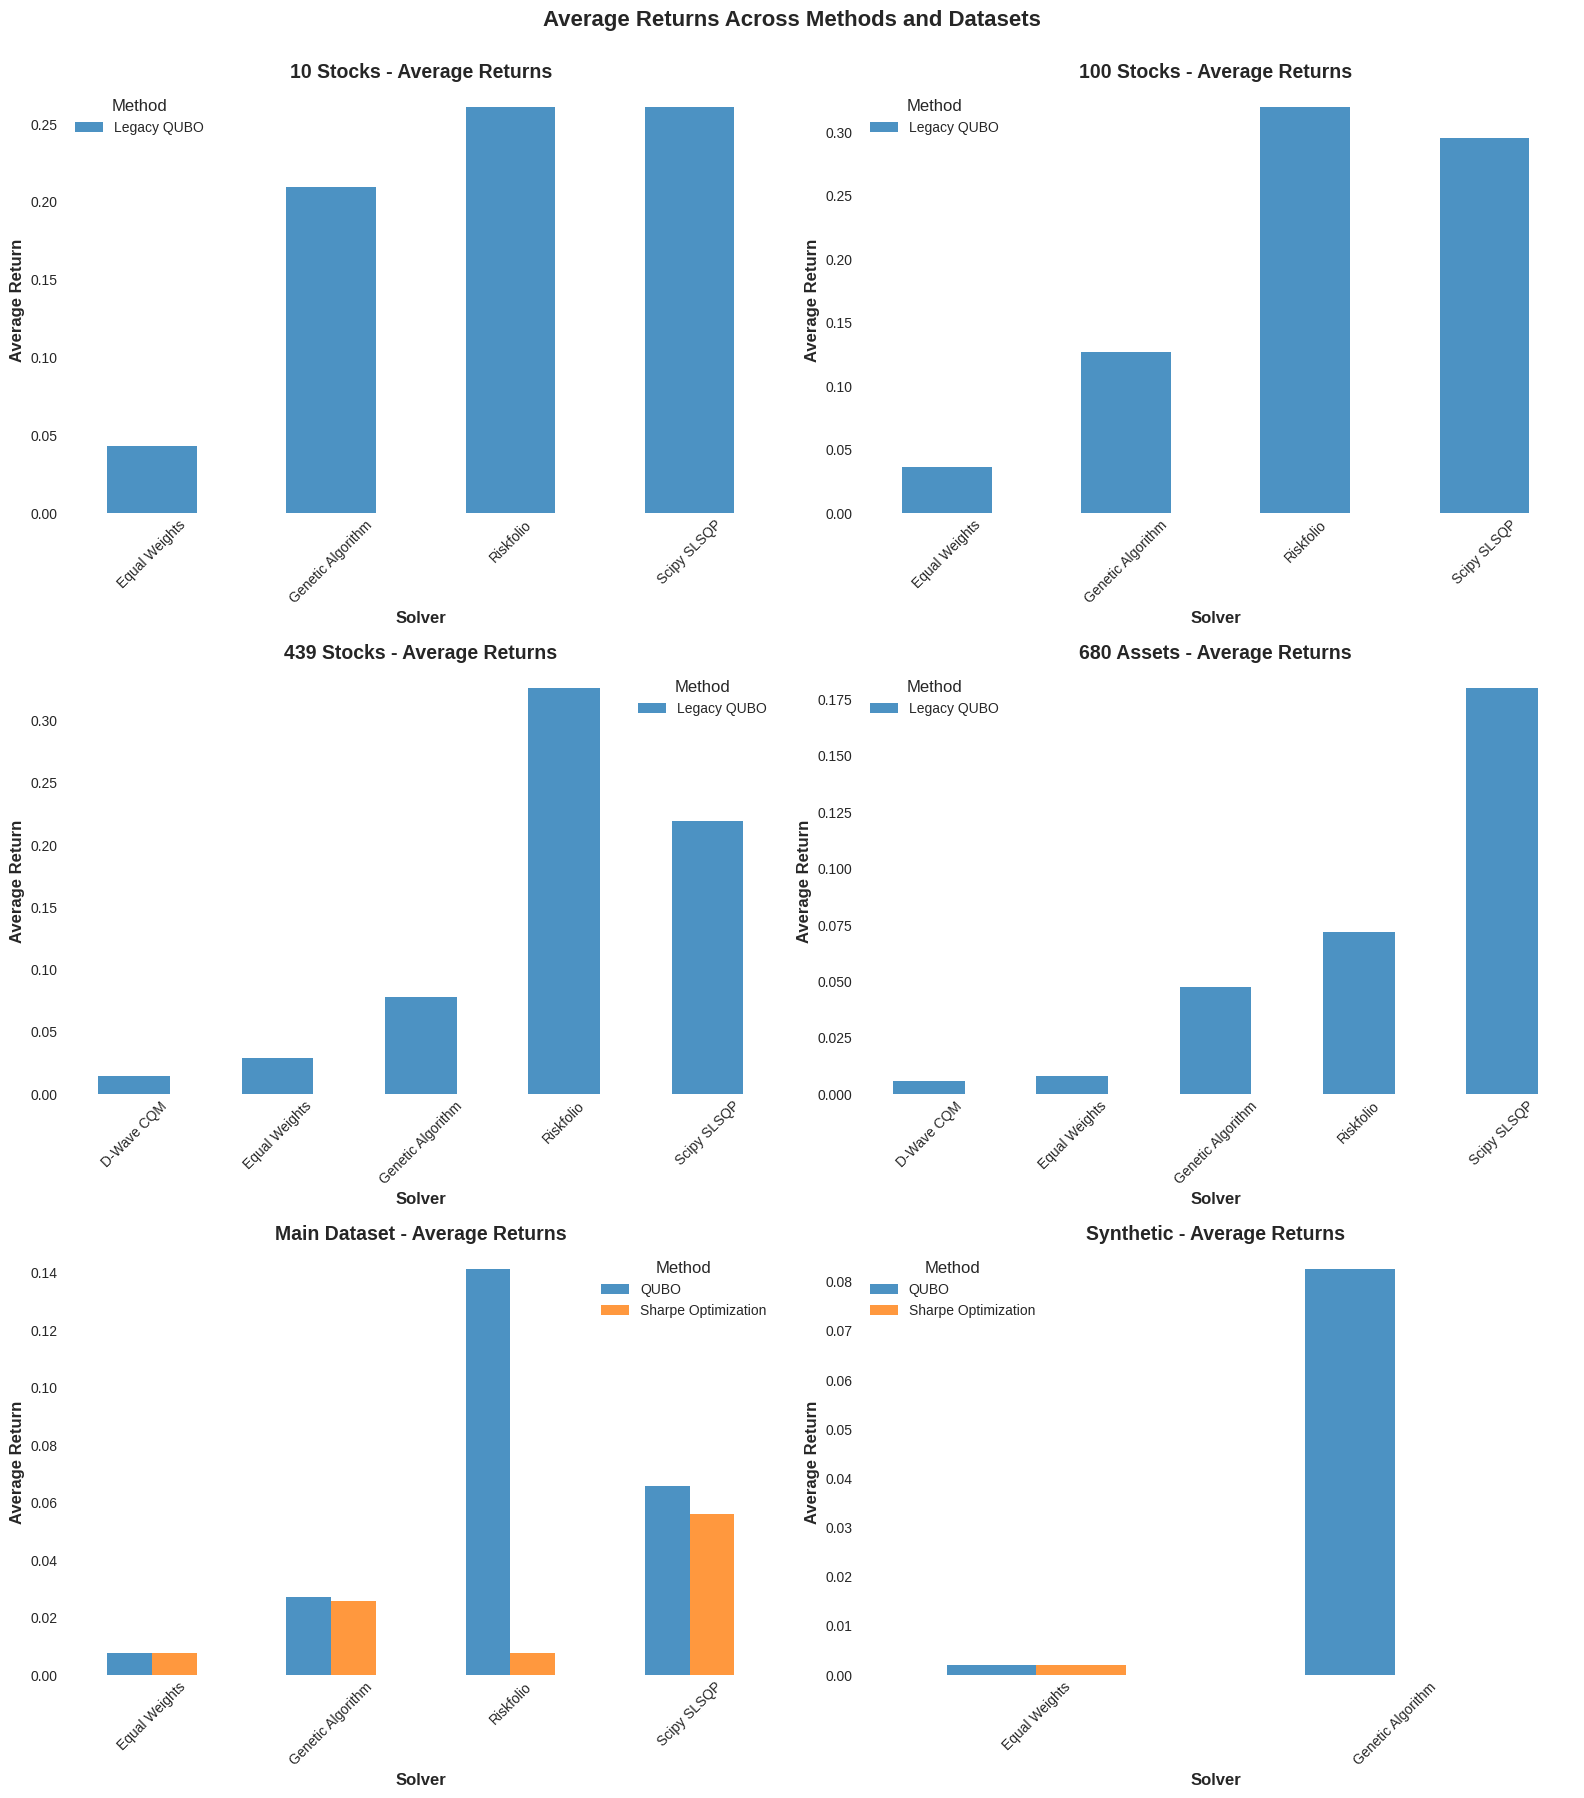

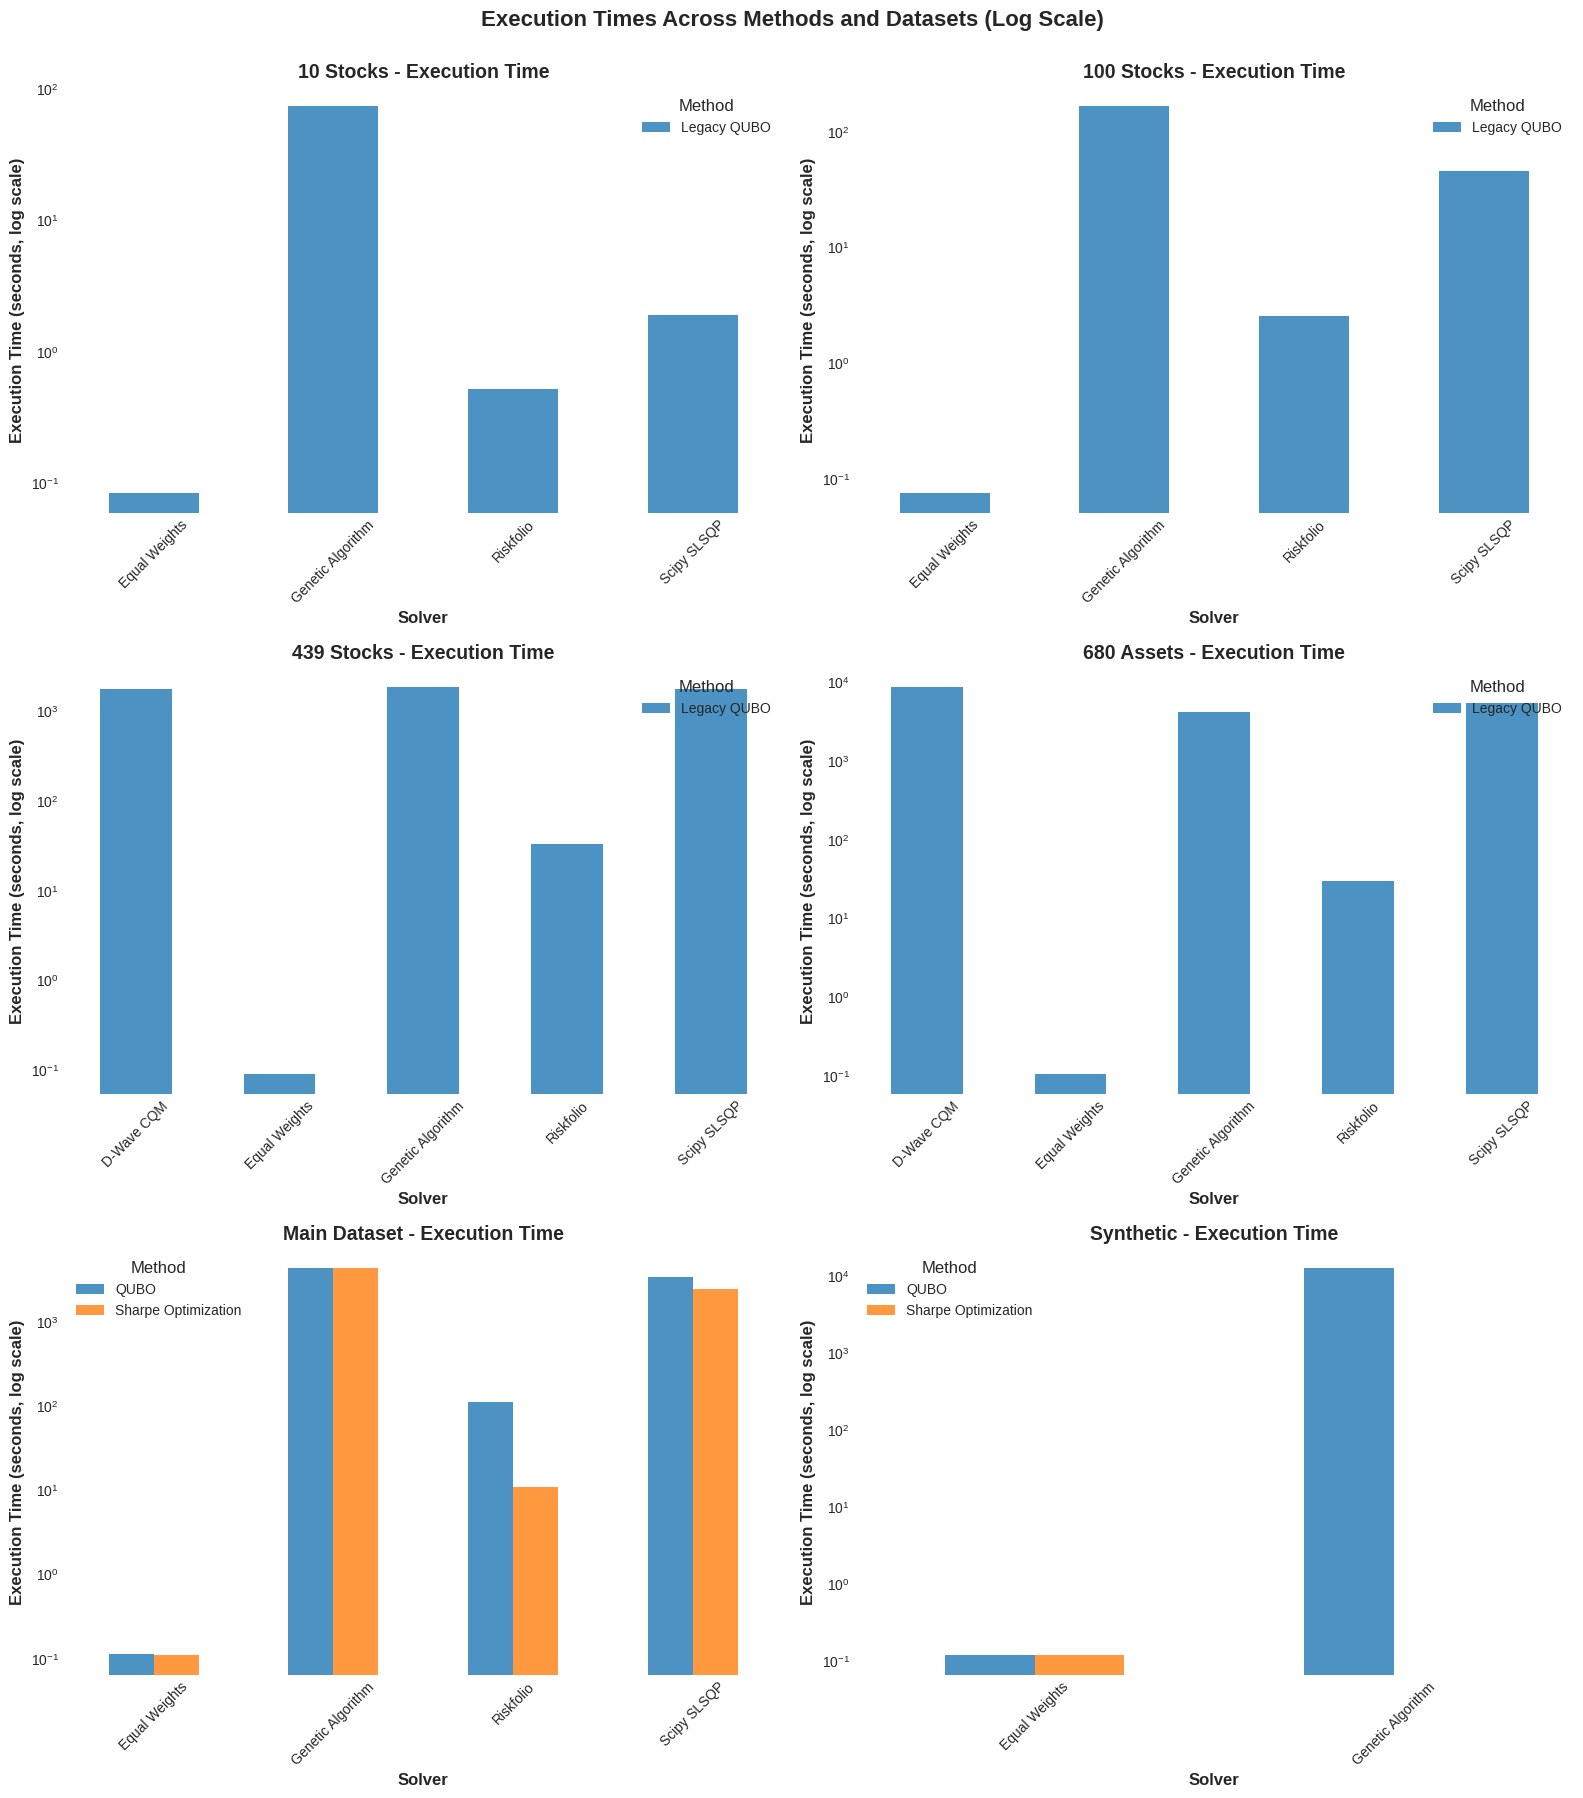

In [8]:
# Create comparison visualizations
if all_stats:
    # Get unique datasets
    datasets = df_all_stats['Dataset'].unique()
    
    # Calculate grid size
    n_datasets = len(datasets)
    n_cols = 2
    n_rows = (n_datasets + 1) // 2
    
    # Plot 1: Returns comparison
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, dataset in enumerate(sorted(datasets)):
        ax = axes[idx]
        
        data = df_all_stats[df_all_stats['Dataset'] == dataset]
        
        if len(data) > 0:
            # Pivot for this dataset
            pivot = data.pivot_table(values='Avg_Return', index='Solver', columns='Method')
            
            pivot.plot(kind='bar', ax=ax, alpha=0.8)
            ax.set_title(f'{dataset} - Average Returns', fontsize=14, fontweight='bold')
            ax.set_xlabel('Solver', fontsize=12, fontweight='bold')
            ax.set_ylabel('Average Return', fontsize=12, fontweight='bold')
            ax.legend(title='Method', loc='best')
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
    
    # Hide unused subplots
    for idx in range(len(datasets), len(axes)):
        axes[idx].axis('off')
    
    fig.suptitle('Average Returns Across Methods and Datasets', 
                 fontsize=16, fontweight='bold', y=0.998)
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Execution time comparison
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, dataset in enumerate(sorted(datasets)):
        ax = axes[idx]
        
        data = df_all_stats[df_all_stats['Dataset'] == dataset]
        
        if len(data) > 0:
            # Pivot for this dataset
            pivot = data.pivot_table(values='Avg_Time', index='Solver', columns='Method')
            
            pivot.plot(kind='bar', ax=ax, alpha=0.8, logy=True)
            ax.set_title(f'{dataset} - Execution Time', fontsize=14, fontweight='bold')
            ax.set_xlabel('Solver', fontsize=12, fontweight='bold')
            ax.set_ylabel('Execution Time (seconds, log scale)', fontsize=12, fontweight='bold')
            ax.legend(title='Method', loc='best')
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
    
    # Hide unused subplots
    for idx in range(len(datasets), len(axes)):
        axes[idx].axis('off')
    
    fig.suptitle('Execution Times Across Methods and Datasets (Log Scale)', 
                 fontsize=16, fontweight='bold', y=0.998)
    plt.tight_layout()
    plt.show()

## D-Wave Results Analysis

Specific analysis of D-Wave CQM results where available.

In [9]:
# Filter D-Wave results
dwave_results = df_results[df_results['solver_name'] == 'D-Wave CQM']

print(f"\n{'='*100}")
print("D-WAVE CQM RESULTS")
print(f"{'='*100}")

if len(dwave_results) > 0:
    print(f"\nFound {len(dwave_results)} D-Wave results")
    print(f"Methods: {dwave_results['method'].unique()}")
    print(f"Datasets: {dwave_results['dataset_name'].unique()}")
    
    # Calculate statistics
    dwave_stats = dwave_results.groupby(['method', 'dataset_name']).agg({
        'final_return': ['mean', 'std', 'min', 'max'],
        'execution_time': ['mean', 'std', 'min', 'max']
    })
    
    print("\nD-Wave Performance Statistics:")
    print(dwave_stats.to_string())
    
    # Compare D-Wave to other solvers
    print("\n" + "="*80)
    print("D-WAVE VS OTHER SOLVERS")
    print("="*80)
    
    for method in dwave_results['method'].unique():
        for dataset in dwave_results['dataset_name'].unique():
            dwave_data = dwave_results[(dwave_results['method'] == method) & 
                                      (dwave_results['dataset_name'] == dataset)]
            other_data = df_results[(df_results['method'] == method) & 
                                   (df_results['dataset_name'] == dataset) &
                                   (df_results['solver_name'] != 'D-Wave CQM')]
            
            if len(dwave_data) > 0 and len(other_data) > 0:
                print(f"\n{method} - {dataset}:")
                print(f"  D-Wave avg return: {dwave_data['final_return'].mean():.4f}")
                print(f"  Other solvers avg return: {other_data['final_return'].mean():.4f}")
                print(f"  D-Wave avg time: {dwave_data['execution_time'].mean():.2f}s")
                print(f"  Other solvers avg time: {other_data['execution_time'].mean():.2f}s")
else:
    print("\nNo D-Wave results found")


D-WAVE CQM RESULTS

Found 21 D-Wave results
Methods: ['Legacy QUBO']
Datasets: ['439 Stocks' '680 Assets' 'synthetic1200']

D-Wave Performance Statistics:
                          final_return                               execution_time                                        
                                  mean       std       min       max           mean         std           min           max
method      dataset_name                                                                                                   
Legacy QUBO 439 Stocks        0.014390  0.019584 -0.013577  0.037132    1716.688140  496.031693    813.601525   2538.989100
            680 Assets        0.005425  0.051612 -0.112687  0.083457    8712.720879  428.594414   8077.168492   9188.944334
            synthetic1200    -0.594103       NaN -0.594103 -0.594103   78681.196349         NaN  78681.196349  78681.196349

D-WAVE VS OTHER SOLVERS

Legacy QUBO - 439 Stocks:
  D-Wave avg return: 0.0144
  Other solvers avg 

## Summary Statistics

In [10]:
print("\n" + "=" * 100)
print("SUMMARY: OVERALL PERFORMANCE BY METHOD")
print("=" * 100)

if all_stats:
    # Calculate aggregate statistics
    print("\nOverall Average Performance:")
    print("-" * 80)
    
    summary_stats = df_all_stats.groupby('Method').agg({
        'Avg_Return': ['mean', 'std', 'min', 'max'],
        'Std_Return': ['mean', 'std'],
        'Avg_Time': ['mean', 'std', 'min', 'max']
    })
    
    print(summary_stats.to_string())
    
    # Best performers by method
    print("\n" + "=" * 100)
    print("BEST PERFORMERS BY METHOD")
    print("=" * 100)
    
    for method in sorted(df_all_stats['Method'].unique()):
        print(f"\n{method}:")
        print("-" * 80)
        
        method_data = df_all_stats[df_all_stats['Method'] == method]
        
        # Best return
        best_return = method_data.loc[method_data['Avg_Return'].idxmax()]
        print(f"  Highest Return: {best_return['Solver']} on {best_return['Dataset']} ({best_return['Avg_Return']:.4f})")
        
        # Lowest risk
        lowest_risk = method_data.loc[method_data['Std_Return'].idxmin()]
        print(f"  Lowest Risk: {lowest_risk['Solver']} on {lowest_risk['Dataset']} ({lowest_risk['Std_Return']:.4f})")
        
        # Fastest
        fastest = method_data.loc[method_data['Avg_Time'].idxmin()]
        print(f"  Fastest: {fastest['Solver']} on {fastest['Dataset']} ({fastest['Avg_Time']:.2f}s)")

print("\n" + "=" * 100)
print("ANALYSIS COMPLETE")
print("=" * 100)


SUMMARY: OVERALL PERFORMANCE BY METHOD

Overall Average Performance:
--------------------------------------------------------------------------------
                    Avg_Return                               Std_Return               Avg_Time                                     
                          mean       std       min       max       mean       std         mean          std       min           max
Method                                                                                                                             
Legacy QUBO           0.140601  0.117381  0.005425  0.326283   0.104985  0.067288  1327.318460  2422.180903  0.074614   8712.720879
QUBO                  0.054344  0.053152  0.002062  0.141234   0.033814  0.014395  3433.199010  4944.047568  0.113239  12748.785131
Sharpe Optimization   0.019805  0.022082  0.002062  0.055973   0.037376  0.005067  1356.036728  1975.581787  0.108785   4358.000953

BEST PERFORMERS BY METHOD

Legacy QUBO:
----------------